In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.animation as animation

# ============================================================
# Utilities
# ============================================================
def wasserstein_distance(u_values, v_values, u_weights=None, v_weights=None):
    """
    Compute the 1D Wasserstein-2 distance between two empirical distributions.

    Parameters
    ----------
    u_values, v_values : array_like
        Values observed in the (empirical) distribution.
    u_weights, v_weights : array_like, optional
        Weight for each value. If unspecified, each value is assigned the same
        weight.

    Returns
    -------
    distance : float
        The computed 1D Wasserstein-2 distance.
    """
    u_values = np.asarray(u_values, dtype=float)
    v_values = np.asarray(v_values, dtype=float)

    # 1. Normalize weights
    if u_weights is None:
        u_weights = np.ones_like(u_values) / len(u_values)
    else:
        u_weights = np.asarray(u_weights, dtype=float)
        u_weights /= np.sum(u_weights)

    if v_weights is None:
        v_weights = np.ones_like(v_values) / len(v_values)
    else:
        v_weights = np.asarray(v_weights, dtype=float)
        v_weights /= np.sum(v_weights)

    # 2. Sort the values and their corresponding weights
    u_sorter = np.argsort(u_values)
    u_values = u_values[u_sorter]
    u_weights = u_weights[u_sorter]

    v_sorter = np.argsort(v_values)
    v_values = v_values[v_sorter]
    v_weights = v_weights[v_sorter]

    # 3. Calculate empirical CDFs
    u_cdf = np.cumsum(u_weights)
    v_cdf = np.cumsum(v_weights)

    # Ensure the CDFs end exactly at 1.0 to avoid floating point errors
    u_cdf[-1] = 1.0
    v_cdf[-1] = 1.0

    # 4. Construct the common axis for the inverse CDFs (quantile functions)
    # The quantile functions change values at the cumulative weights.
    cdf_axis = np.unique(np.concatenate((u_cdf, v_cdf)))
    cdf_axis = np.insert(cdf_axis, 0, 0.0)

    # Calculate the widths of the integration intervals
    widths = np.diff(cdf_axis)

    # 5. Evaluate the inverse CDFs on each interval
    # We evaluate at the midpoints of the steps to ensure we grab the correct value
    midpoints = cdf_axis[:-1] + widths / 2

    # Handle single-point distributions specifically
    if len(u_values) == 1:
        u_quantiles = np.full_like(midpoints, u_values[0])
    else:
        u_quantiles = u_values[np.searchsorted(u_cdf, midpoints)]

    if len(v_values) == 1:
        v_quantiles = np.full_like(midpoints, v_values[0])
    else:
        v_quantiles = v_values[np.searchsorted(v_cdf, midpoints)]

    # 6. W2 distance is the square root of the integral of the squared differences
    w2_squared = np.sum((u_quantiles - v_quantiles)**2 * widths)

    return np.sqrt(w2_squared)


# ============================================================
# 1. Slingshot Stepsize Scheduler
# ============================================================
def get_slingshot_steps(problem_type, t, T,
                        L=None, m=None, M=None,
                        rng=None,
                        use_slingshot=True):
    """
    Returns (alpha_t, beta_t).

    use_slingshot=True  → Shugart's negative-stepsize schedule
    use_slingshot=False → vanilla constant positive stepsizes (Chizat baseline)

    Bilinear  : Chebyshev schedule on singular-value spectrum [m, M]
    Nonlinear : randomised symmetry-breaking with h = 1/(3L)
    """
    rng = rng or np.random.default_rng()

    if not use_slingshot:
        # Vanilla: constant positive step, same for both players
        h = (1.0 / np.sqrt(M)) if (problem_type == "bilinear" and M is not None) \
            else 1.0 / (3.0 * L)
        return h, h

    if problem_type == "bilinear":
        k   = t // 2
        r_t = (M + m) / 2 + (M - m) / 2 * np.cos((2 * k + 1) * np.pi / (2 * T))
        h   = 1.0 / np.sqrt(r_t)
        return (h, -h) if t % 2 == 0 else (-h, h)
    else:
        h = 1.0 / (3.0 * L)
        if t % 2 == 0:
            return (h, -h) if rng.random() < 0.5 else (-h, h)
        else:
            return h, h


# ============================================================
# 2. Conic Particle MDA
# ============================================================
class ConicParticles:
    def __init__(self, n, m, d, rng=None):
        rng = rng or np.random.default_rng()
        self.a = np.ones(n) / n
        self.x = rng.uniform(-3, 3, (n, d))
        self.b = np.ones(m) / m
        self.y = rng.uniform(-3, 3, (m, d))

    def update_mda(self, grad_a, grad_x, grad_b, grad_y, alpha, beta):
        # Save weights BEFORE updating — critical: avoids feedback loop
        a_old = self.a.copy()
        b_old = self.b.copy()

        # ---- Player 1 (Descent) ----
        log_a  = np.log(np.maximum(a_old, 1e-15)) - alpha * grad_a
        log_a -= np.max(log_a)                         # log-sum-exp shift
        self.a = np.exp(log_a)
        self.a /= np.sum(self.a)

        denom_x  = np.maximum(a_old[:, None], 1e-3)
        clip_val = np.minimum(1.0, 0.1 / denom_x)     # adaptive clip
        step_x   = alpha * grad_x / denom_x
        self.x  -= np.clip(step_x, -clip_val, clip_val)

        # ---- Player 2 (Ascent) ----
        log_b  = np.log(np.maximum(b_old, 1e-15)) + beta * grad_b
        log_b -= np.max(log_b)
        self.b = np.exp(log_b)
        self.b /= np.sum(self.b)

        denom_y    = np.maximum(b_old[:, None], 1e-3)
        clip_val_y = np.minimum(1.0, 0.1 / denom_y)
        step_y     = beta * grad_y / denom_y
        self.y    += np.clip(step_y, -clip_val_y, clip_val_y)

        # Domain projection (essential for bilinear)
        M = 10.0
        self.x = np.clip(self.x, -1*M, M)
        self.y = np.clip(self.y, -1*M, M)


# ============================================================
# 2b. Vanilla Chizat Baseline — raw paper equations, no stabilisation
# ============================================================
class ConicParticlesChizat:
    """
    Faithful implementation of Chizat's CP-MDA as written in the paper.

    Differences from ConicParticles (the stabilised version):
      - Weight update: plain exp/normalise — NO log-sum-exp shift.
        Overflow to inf will occur if alpha * grad_a is large; this is
        intentional so we can observe the raw algorithm's behaviour.
      - Position update: divided by a_i directly — NO floor at 1e-3,
        NO adaptive clip, NO uniform clip.
      - NO domain projection.

    This class exists solely as a truthful baseline against which the
    stabilised slingshot variant can be compared.  Do not use it as the
    production solver.
    """
    def __init__(self, n, m, d, rng=None):
        rng = rng or np.random.default_rng()
        self.a = np.ones(n) / n
        self.x = rng.uniform(-3, 3, (n, d))
        self.b = np.ones(m) / m
        self.y = rng.uniform(-3, 3, (m, d))

    def update_mda(self, grad_a, grad_x, grad_b, grad_y, alpha, beta):
        # Save weights BEFORE updating — critical: avoids feedback loop
        a_old = self.a.copy()
        b_old = self.b.copy()

        # ---- Player 1 (Descent) ----
        # Use log-sum-exp trick to prevent overflow
        log_a  = np.log(np.maximum(a_old, 1e-15)) - alpha * grad_a
        log_a -= np.max(log_a) # log-sum-exp shift
        self.a = np.exp(log_a)
        self.a /= np.sum(self.a)

        # Raw preconditioned position update: step = alpha * grad / a_i
        # No clipping, no flooring of the denominator
        safe_a = np.where(self.a > 0, self.a, np.nan)   # NaN signals blown-up ghost
        self.x -= alpha * grad_x / safe_a[:, None]

        # ---- Player 2 (Ascent) ----
        # Use log-sum-exp trick to prevent overflow
        log_b  = np.log(np.maximum(b_old, 1e-15)) + beta * grad_b
        log_b -= np.max(log_b)
        self.b = np.exp(log_b)
        self.b /= np.sum(self.b)

        safe_b = np.where(self.b > 0, self.b, np.nan)
        self.y += beta * grad_y / safe_b[:, None]


# ============================================================
# 3. Objective Functions & Gradients
# ============================================================
def f_bilinear(x, y, B):    return (x @ B @ y).item() # Ensure scalar output
def grad_bilinear(x, y, B): return B @ y, B.T @ x

def logcosh(x):
    s = np.sign(x) * x
    return s + np.log1p(np.exp(-2 * s)) - np.log(2.0)

def f_convex_concave(x, y):    return (logcosh(x) - logcosh(y)).item() # Explicitly get scalar
def grad_convex_concave(x, y): return np.tanh(x), -np.tanh(y)

def f_sc_sc(x, y, mu=1.0):
    return (0.5*mu*np.sum(x**2) - 0.5*mu*np.sum(y**2) + np.sum(x*y)).item() # Ensure scalar output
def grad_sc_sc(x, y, mu=1.0): return mu*x + y, -mu*y + x


# ============================================================
# 4. Diagnostic Helpers
# ============================================================
def get_weighted_barycenter(weights, positions):
    """Expected strategy: Σ a_i x_i."""
    return np.sum(weights[:, None] * positions, axis=0)

def entropy(weights):
    """Shannon entropy H(a) = -Σ a_i log a_i. Zero iff Dirac delta."""
    w = np.maximum(weights, 1e-15)
    return float(-np.sum(w * np.log(w)))

def duality_gap(a, x, b, y, f_func):
    """
    Exploitability / duality gap:
      gap = max_j Σ₁ a_i f(x_i, y_j)  −  min_i Σ₇ b_j f(x_i, y_j)  ≥ 0
    Equals zero iff (μ,ν) is an MNE.
    """
    vals = np.array([[f_func(x[i], y[j])
                      for j in range(len(y))] for i in range(len(x))])
    return float(np.max(vals.T @ a) - np.min(vals @ b))

def wasserstein_to_mne(weights, positions, mne_pos=0.0):
    """
    1-D Wasserstein-2 distance between the particle measure Σ a_i δ_{x_i}
    and the target MNE Dirac δ_{mne_pos}.
    """
    return wasserstein_distance(
        positions[:, 0], np.array([mne_pos]),
        u_weights=weights, v_weights=np.array([1.0])
    )

def compute_regret(gap_history):
    """
    Cumulative average regret: R_T = (1/T) Σ_{t=1}^{T} gap_t.
    Uses duality gap as per-step regret proxy; forward-fills NaN entries.
    """
    gaps = np.array(gap_history, dtype=float)
    for i in range(1, len(gaps)):
        if np.isnan(gaps[i]):
            gaps[i] = gaps[i-1]
    return np.cumsum(gaps) / (np.arange(len(gaps)) + 1)

def f_mixture(a, x, b, y, f_func):
    """F(μ_t, ν_t) — value of the objective at the current iterate."""
    return sum(
        a[i] * b[j] * f_func(x[i], y[j])
        for i in range(len(x)) for j in range(len(y))
    )


# ============================================================
# 5. Experiment Runner
# ============================================================
def run_experiment(model, grad_func, f_func, steps=200,
                   problem_type="bilinear", T=None,
                   L=None, m=None, M=None,
                   rng=None, use_slingshot=True,
                   w2_threshold=None): # Changed from entropy_threshold to w2_threshold
    """
    Runs CP-MDA and records full diagnostic history.

    Parameters
    ----------
    model : ConicParticles | ConicParticlesChizat
        Pass ConicParticles      for the stabilised slingshot variant.
        Pass ConicParticlesChizat for the raw Chizat baseline.
        The model's update_mda() method is called regardless of class —
        each class implements its own version of the update.
    use_slingshot : bool
        True  → Shugart's negative-stepsize schedule (Chebyshev / randomised).
        False → constant positive stepsize h for both players.
        For the Chizat baseline, always pass use_slingshot=False so that
        the stepsize schedule also matches the paper.

    Returns
    -------
    history : dict with keys
        a, x, b, y        — particle states at each step
        barycenter         — weighted mean (\bar{x}_t, \bar{y}_t)
        entropy_a/b        — H(a_t), H(b_t)
        hamiltonian        — ½‖∇f(\bar{x},ȳ)‖²
        gap                — duality gap (every 10 steps, else NaN)
        f_val              — F(μ_t, ν_t)
        w2_a / w2_b        — W₂(μ_t, δ₀) / W₂(ν_t, δ₀)
        regret             — cumulative average regret
    """
    rng = rng or np.random.default_rng()
    T   = T or steps

    history = {
        'a': [], 'x': [], 'b': [], 'y': [],
        'barycenter'  : [],
        'entropy_a'   : [], 'entropy_b'   : [],
        'hamiltonian' : [],
        'gap'         : [],
        'f_val'       : [],
        'w2_a'        : [], 'w2_b'        : [],
    }

    for t in range(steps):
        # ---- Record state ----
        history['a'].append(model.a.copy())
        history['x'].append(model.x.copy())
        history['b'].append(model.b.copy())
        history['y'].append(model.y.copy())

        xb = get_weighted_barycenter(model.a, model.x)[0]
        yb = get_weighted_barycenter(model.b, model.y)[0]
        history['barycenter'].append((xb, yb))

        history['entropy_a'].append(entropy(model.a))
        history['entropy_b'].append(entropy(model.b))

        # --- Early stopping condition ---
        # Removed problem_type == "bilinear" condition for general W2 early stop
        if w2_threshold is not None:
            # Need to compute W2 before potentially breaking, to record it for current step
            current_w2_a = wasserstein_to_mne(model.a, model.x)
            current_w2_b = wasserstein_to_mne(model.b, model.y)
            history['w2_a'].append(current_w2_a)
            history['w2_b'].append(current_w2_b)
            if current_w2_a < w2_threshold or current_w2_b < w2_threshold:
                print(f"  Early stopping at step {t} due to Wasserstein-2 distance falling below {w2_threshold}.")
                break
        else:
            # If no W2 threshold, compute and record normally
            history['w2_a'].append(wasserstein_to_mne(model.a, model.x))
            history['w2_b'].append(wasserstein_to_mne(model.b, model.y))

        # --------------------------------

        gx0, gy0 = grad_func(np.array([xb]), np.array([yb]))
        history['hamiltonian'].append(
            0.5 * (float(np.sum(gx0**2)) + float(np.sum(gy0**2))))

        history['f_val'].append(
            f_mixture(model.a, model.x, model.b, model.y, f_func))


        # Duality gap every 10 steps (O(n²))
        if t % 10 == 0:
            history['gap'].append(
                duality_gap(model.a, model.x, model.b, model.y, f_func))
        else:
            history['gap'].append(np.nan)

        # ---- Compute gradients ----
        alpha, beta = get_slingshot_steps(
            problem_type, t, T, L=L, m=m, M=M,
            rng=rng, use_slingshot=use_slingshot)

        n_, m_ = model.x.shape[0], model.y.shape[0]
        grad_x = np.zeros_like(model.x)
        grad_y = np.zeros_like(model.y)
        grad_a = np.zeros(n_)
        grad_b = np.zeros(m_)

        for i in range(n_):
            for j in range(m_):
                gx, gy = grad_func(model.x[i], model.y[j])
                val    = f_func(model.x[i], model.y[j]) # f_func now returns scalar
                grad_x[i] += model.b[j] * gx.item() # Explicitly get scalar
                grad_y[j] += model.a[i] * gy.item() # Explicitly get scalar
                grad_a[i] += model.b[j] * val
                grad_b[j] += model.a[i] * val

        model.update_mda(grad_a, grad_x, grad_b, grad_y, alpha, beta)

    history['regret'] = list(compute_regret(history['f_val']))
    return history


# ============================================================
# 6. Dashboard  — 3×3 grid, static, notebook-viewable + saveable
# ============================================================
def plot_dashboard(history, grad_func, title="", save_path=None):
    """
    3×3 grid:
      [0,0] Hamiltonian landscape + barycenter + final particles
      [0,1] Barycenter distance to origin (log)
      [0,2] F(μ_t, ν_t) — value at iterate
      [1,0] Strategy entropy H(a), H(b)
      [1,1] Duality gap (log)
      [1,2] Cumulative average regret (log)
      [2,0] Final P1 strategy mass histogram
      [2,1] Final P2 strategy mass histogram
      [2,2] Wasserstein W₂ to MNE (log) # Updated to W2
    """
    fig = plt.figure(figsize=(18, 13))
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.01)
    gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.48, wspace=0.35)
    axs = [[fig.add_subplot(gs[r, c]) for c in range(3)] for r in range(3)]

    # ---- [0,0] Landscape ----
    xs = np.linspace(-3, 3, 80)
    X, Y = np.meshgrid(xs, xs)
    Z = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            gx, gy = grad_func(np.array([X[i, j]]), np.array([Y[i, j]])) # gx, gy are 1-element arrays
            Z[i, j] = 0.5 * (gx.item()**2 + gy.item()**2) # Use .item() to extract scalar
    axs[0][0].contourf(X, Y, Z, levels=30, cmap='Blues', alpha=0.5)

    traj = np.array(history['barycenter'])
    mask = ~np.isnan(traj).any(axis=1)
    tc   = traj[mask]
    if len(tc):
        axs[0][0].plot(tc[:, 0], tc[:, 1], 'k-', lw=1.5, label='Barycenter', zorder=3)
        axs[0][0].scatter(*tc[0],  c='white',  edgecolors='k', s=80,  zorder=4, label='Start')
        axs[0][0].scatter(*tc[-1], c='yellow', edgecolors='k', s=280,
                           marker='*', zorder=5, label='End')

    a_f, x_f = history['a'][-1], history['x'][-1]
    b_f, y_f = history['b'][-1], history['y'][-1]

    # Filter out NaN values for plotting final particles
    valid_p1 = ~np.isnan(x_f[:, 0])
    x_f_valid = x_f[valid_p1, 0]
    a_f_valid = a_f[valid_p1]

    valid_p2 = ~np.isnan(y_f[:, 0])
    y_f_valid = y_f[valid_p2, 0]
    b_f_valid = b_f[valid_p2]

    if len(x_f_valid) > 0:
        axs[0][0].scatter(x_f_valid, np.full(len(x_f_valid), -0.1),
                          s=np.maximum(a_f_valid * 2000, 5), c='red',
                          alpha=0.8, edgecolors='k', zorder=5, label='P1')
    if len(y_f_valid) > 0:
        axs[0][0].scatter(np.full(len(y_f_valid), 0.1), y_f_valid,
                          s=np.maximum(b_f_valid * 2000, 5), c='orange',
                          alpha=0.8, edgecolors='k', zorder=5, label='P2')

    axs[0][0].set_xlim(-3, 3); axs[0][0].set_ylim(-3, 3)
    axs[0][0].set_title("Hamiltonian + Particles", fontsize=10)
    axs[0][0].legend(fontsize=6, loc='upper right')

    # ---- [0,1] Log barycenter distance ----
    if len(tc):
        dist = np.sqrt(tc[:, 0]**2 + tc[:, 1]**2)
        axs[0][1].semilogy(dist, c='purple', lw=1.8)
    axs[0][1].set_title("Barycenter Distance (log)", fontsize=10)
    axs[0][1].set_xlabel("Iteration"); axs[0][1].set_ylabel("‖bary‖")
    axs[0][1].grid(True, ls='--', alpha=0.5)

    # ---- [0,2] F(μ_t, ν_t) ----
    fvals = np.array(history['f_val'])
    axs[0][2].plot(fvals, c='steelblue', lw=1.8)
    axs[0][2].axhline(0, color='k', ls='--', lw=1, label='MNE value = 0')
    axs[0][2].set_title("F(μ_t, ν_t) — iterate value", fontsize=10)
    axs[0][2].set_xlabel("Iteration"); axs[0][2].set_ylabel("F")
    axs[0][2].legend(fontsize=7); axs[0][2].grid(True, ls='--', alpha=0.5)

    # ---- [1,0] Entropy ----
    ea = np.array(history['entropy_a'])
    eb = np.array(history['entropy_b'])
    axs[1][0].plot(ea, c='red',    lw=1.8, label='H(a) — P1')
    axs[1][0].plot(eb, c='orange', lw=1.8, label='H(b) — P2')
    axs[1][0].axhline(0, color='k', ls='--', lw=1, label='Target 0')
    axs[1][0].set_title("Strategy Entropy  (↓ = mass collapse)", fontsize=10)
    axs[1][0].set_xlabel("Iteration"); axs[1][0].set_ylabel("H")
    axs[1][0].legend(fontsize=7); axs[1][0].grid(True, ls='--', alpha=0.5)

    # ---- [1,1] Duality gap ----
    gap = np.array(history['gap'])
    vi  = ~np.isnan(gap)
    if vi.any():
        axs[1][1].semilogy(np.where(vi)[0], gap[vi], 'g-o', lw=1.8, ms=3, label='Gap')
    axs[1][1].axhline(1e-2, color='red', ls='--', lw=1, label='ε=0.01')
    axs[1][1].set_title("Duality Gap  (↓ = Nash)", fontsize=10)
    axs[1][1].set_xlabel("Iteration"); axs[1][1].set_ylabel("Gap (log)")
    axs[1][1].legend(fontsize=7); axs[1][1].grid(True, ls='--', alpha=0.5)

    # ---- [1,2] Regret ----
    regret = np.array(history['regret'])
    axs[1][2].semilogy(regret, c='brown', lw=1.8)
    axs[1][2].set_title("Cumulative Avg Regret  (↓ = no-regret)", fontsize=10)
    axs[1][2].set_xlabel("Iteration"); axs[1][2].set_ylabel("R_T (log)")
    axs[1][2].grid(True, ls='--', alpha=0.5)

    # ---- [2,0] Final P1 histogram ----
    if len(x_f_valid) > 0:
        axs[2][0].bar(x_f_valid, a_f_valid, width=0.12, color='red', alpha=0.8, edgecolor='k')
    axs[2][0].axvline(0, color='k', ls='--', lw=1, label='x*=0')
    axs[2][0].set_xlim(-3, 3); axs[2][0].set_ylim(0, 1.05)
    axs[2][0].set_title("Final P1 Strategy Mass", fontsize=10)
    axs[2][0].set_xlabel("x"); axs[2][0].set_ylabel("a_i")
    axs[2][0].legend(fontsize=7)

    # ---- [2,1] Final P2 histogram ----
    if len(y_f_valid) > 0:
        axs[2][1].bar(y_f_valid, b_f_valid, width=0.12, color='orange', alpha=0.8, edgecolor='k')
    axs[2][1].axvline(0, color='k', ls='--', lw=1, label='y*=0')
    axs[2][1].set_xlim(-3, 3); axs[2][1].set_ylim(0, 1.05)
    axs[2][1].set_title("Final P2 Strategy Mass", fontsize=10)
    axs[2][1].set_xlabel("y"); axs[2][1].set_ylabel("b_j")
    axs[2][1].legend(fontsize=7)

    # ---- [2,2] Wasserstein to MNE ----
    w2a = np.array(history['w2_a'])
    w2b = np.array(history['w2_b'])
    axs[2][2].semilogy(w2a, c='red',    lw=1.8, label='W₂(μ_t, δ₀)') # Updated to W2
    axs[2][2].semilogy(w2b, c='orange', lw=1.8, label='W₂(ν_t, δ₀)') # Updated to W2
    axs[2][2].set_title("Wasserstein Dist to MNE  (↓ = converged)", fontsize=10)
    axs[2][2].set_xlabel("Iteration"); axs[2][2].set_ylabel("W₂ (log)") # Updated to W2
    axs[2][2].legend(fontsize=7); axs[2][2].grid(True, ls='--', alpha=0.5)

    # plt.tight_layout() # Removed to avoid UserWarning with gridspec

    if save_path:
        fig.savefig(save_path, dpi=110, bbox_inches='tight')
        print(f"  Saved → {save_path}")

    return fig


# ============================================================
# 7. GIF Generator
# ============================================================
def animate_convergence(history, grad_func, filename="convergence.gif", title=""):
    """
    4-panel animated GIF:
      [0] Hamiltonian landscape + particles + barycenter path
      [1] P1 probability mass histogram (entropy shown in title)
      [2] P2 probability mass histogram (entropy shown in title)
      [3] Entropy (left axis, solid) + Wasserstein W₂ (right axis, dashed, log) # Updated to W2
    """
    fig, axs = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(title, fontsize=11, fontweight='bold')

    # Pre-compute static Hamiltonian background
    xs = np.linspace(-3, 3, 80)
    X, Y = np.meshgrid(xs, xs)
    Z = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            gx, gy = grad_func(np.array([X[i, j]]), np.array([Y[i, j]]))
            Z[i, j] = 0.5 * (gx.item()**2 + gy.item()**2) # Use .item() to extract scalar
    axs[0].contourf(X, Y, Z, levels=30, cmap='Blues', alpha=0.4)

    scat_p1   = axs[0].scatter([], [], c='red',    edgecolors='k', zorder=5)
    scat_p2   = axs[0].scatter([], [], c='orange', edgecolors='k', zorder=4)
    line_bary, = axs[0].plot([], [], 'k-', lw=1.5, zorder=2)
    scat_bary  = axs[0].scatter([], [], c='yellow', edgecolors='k',
                                 marker='*', s=250, zorder=10)
    axs[0].set_xlim(-3, 3); axs[0].set_ylim(-3, 3)
    axs[0].set_title("State Space", fontsize=9)

    steps_range = np.arange(len(history['a']))
    ea  = np.array(history['entropy_a'])
    eb  = np.array(history['entropy_b'])
    w2a = np.array(history['w2_a'])
    w2b = np.array(history['w2_b'])

    # twin axis for right panel (Wasserstein on log scale)
    ax3b = axs[3].twinx()

    def update(frame):
        a, x = history['a'][frame], history['x'][frame]
        b, y = history['b'][frame], history['y'][frame]

        # Filter out NaN values for plotting animated particles
        valid_p1_anim = ~np.isnan(x[:, 0])
        x_anim_valid = x[valid_p1_anim, 0]
        a_anim_valid = a[valid_p1_anim]

        valid_p2_anim = ~np.isnan(y[:, 0])
        y_anim_valid = y[valid_p2_anim, 0]
        b_anim_valid = b[valid_p2_anim]

        # Landscape: move particles and barycenter
        if len(x_anim_valid) > 0:
            scat_p1.set_offsets(np.c_[x_anim_valid, np.full(len(x_anim_valid), -0.05)])
            scat_p1.set_sizes(np.maximum(a_anim_valid * 1500, 5))
        else:
            scat_p1.set_offsets(np.empty((0, 2)))
            scat_p1.set_sizes(np.empty(0))

        if len(y_anim_valid) > 0:
            scat_p2.set_offsets(np.c_[np.full(len(y_anim_valid), 0.05), y_anim_valid])
            scat_p2.set_sizes(np.maximum(b_anim_valid * 1500, 5))
        else:
            scat_p2.set_offsets(np.empty((0, 2)))
            scat_p2.set_sizes(np.empty(0))

        bp = np.array(history['barycenter'][:frame+1])
        line_bary.set_data(bp[:, 0], bp[:, 1])
        scat_bary.set_offsets([bp[-1]])

        # P1 histogram
        axs[1].clear()
        axs[1].set_xlim(-3, 3); axs[1].set_ylim(0, 1.05)
        axs[1].set_title(f"P1 Mass   H={ea[frame]:.3f}", fontsize=8)
        if len(x_anim_valid) > 0:
            axs[1].bar(x_anim_valid, a_anim_valid, width=0.13, color='red', alpha=0.75, edgecolor='k')
        axs[1].axvline(0, color='k', ls='--', lw=0.8)
        axs[1].set_xlabel("x", fontsize=7); axs[1].set_ylabel("a_i", fontsize=7)

        # P2 histogram
        axs[2].clear()
        axs[2].set_xlim(-3, 3); axs[2].set_ylim(0, 1.05)
        axs[2].set_title(f"P2 Mass   H={eb[frame]:.3f}", fontsize=8)
        if len(y_anim_valid) > 0:
            axs[2].bar(y_anim_valid, b_anim_valid, width=0.13, color='orange', alpha=0.75, edgecolor='k')
        axs[2].axvline(0, color='k', ls='--', lw=0.8)
        axs[2].set_xlabel("y", fontsize=7)

        # Entropy (solid) + Wasserstein (dashed, log) — right panel
        sr = steps_range[:frame+1]
        axs[3].clear(); ax3b.clear()
        axs[3].plot(sr, ea[:frame+1], 'r-',           lw=1.4, label='H(a)')
        axs[3].plot(sr, eb[:frame+1], color='orange',  lw=1.4, label='H(b)')
        ax3b.semilogy(sr, w2a[:frame+1], 'r--',           lw=1.0, alpha=0.65, label='W₂(μ)') # Updated to W2
        ax3b.semilogy(sr, w2b[:frame+1], color='orange',  lw=1.0, ls='--',
                      alpha=0.65, label='W₂(ν)') # Updated to W2
        axs[3].set_xlim(0, len(history['a']))
        axs[3].set_ylim(-0.05, np.log(len(a)) + 0.3)
        axs[3].set_title("H (solid) / W₂ (dashed)", fontsize=8) # Updated to W2
        axs[3].set_xlabel("t", fontsize=7)
        axs[3].set_ylabel("H", fontsize=7)
        ax3b.set_ylabel("W₂ (log)", fontsize=7) # Updated to W2
        axs[3].legend(fontsize=6, loc='upper left')
        ax3b.legend(fontsize=6, loc='upper right')
        axs[3].grid(True, ls='--', alpha=0.35)

    print(f"  Generating {filename}  ({len(history['a'])} frames) ...")
    ani = animation.FuncAnimation(fig, update, frames=len(history['a']), interval=80)
    ani.save(filename, writer='pillow')
    plt.close(fig)
    print("  Done!")


# ============================================================
# 8. Driver  — structured as 4 notebook cells
# ============================================================
if __name__ == "__main__":

    rng = np.random.default_rng(42)

    B_mat  = np.array([[1.0]])
    N_PART = 30
    D      = 1

    CASES = [
        dict(name="bilinear",
             label="Bilinear",
             grad=lambda x, y: grad_bilinear(x, y, B_mat),
             f   =lambda x, y: f_bilinear(x, y, B_mat),
             ptype="bilinear",  steps_sl=1000, steps_van=1000,
             steps_off=1000, L=None, m=1.0, M=1.0),
        dict(name="convex_concave",
             label="Convex-Concave",
             grad=grad_convex_concave,
             f   =f_convex_concave,
             ptype="nonlinear", steps_sl=1000, steps_van=1000,
             steps_off=1000, L=1.0, m=None, M=None),
        dict(name="scsc",
             label="SC-SC",
             grad=lambda x, y: grad_sc_sc(x, y, mu=1.0),
             f   =lambda x, y: f_sc_sc(x, y, mu=1.0),
             ptype="nonlinear", steps_sl=1000,  steps_van=1000,
             steps_off=1000, L=float(np.sqrt(2)), m=None, M=None),
    ]

    histories = {}   # retain for GIF cells below

    # ----------------------------------------------------------
    # CELL 1 — Dashboards: Slingshot ON
    # ----------------------------------------------------------
    print("=" * 55)
    print("CELL 1 — Dashboards  (Slingshot ON)")
    print("=" * 55)
    for c in CASES:
        print(f"\n  {c['label']}  (slingshot, {c['steps_sl']} steps)")
        model = ConicParticles(n=N_PART, m=N_PART, d=D, rng=rng)

        h = run_experiment(
            model, c['grad'], c['f'],
            steps=c['steps_sl'], problem_type=c['ptype'],
            L=c['L'], m=c['m'], M=c['M'],
            rng=rng, use_slingshot=True,
            w2_threshold=0.0 # Pass the threshold for all cases
        )
        histories[f"sl_{c['name']}"] = (h, c['grad'])
        # fig = plot_dashboard(
        #     h, c['grad'],
        #     title=f"{c['label']} — CP-MDA  (Slingshot)",
        #     save_path=f"cpmda_{c['name']}_dashboard.png"
        # )
        # plt.show()
        # plt.close(fig)

    # ----------------------------------------------------------
    # CELL 2 — Dashboards: Slingshot OFF
    # ----------------------------------------------------------
    print("=" * 55)
    print("CELL 2 — Dashboards  (Slingshot OFF)")
    print("=" * 55)
    for c in CASES:
        print(f"\n  {c['label']}  (slingshot, {c['steps_off']} steps)")
        model = ConicParticles(n=N_PART, m=N_PART, d=D, rng=rng)
        h = run_experiment(
            model, c['grad'], c['f'],
            steps=c['steps_sl'], problem_type=c['ptype'],
            L=c['L'], m=c['m'], M=c['M'],
            rng=rng, use_slingshot=False,
            w2_threshold=0.0 # Pass the threshold for all cases
        )
        histories[f"off_{c['name']}"] = (h, c['grad'])
        # fig = plot_dashboard(
        #     h, c['grad'],
        #     title=f"{c['label']} — CP-MDA  (w/o Slingshot)",
        #     save_path=f"cpmda_{c['name']}_w_o_Slingshot_dashboard.png"
        # )
        # plt.show()
        # plt.close(fig)

    # ----------------------------------------------------------
    # CELL 3 — Dashboards: Vanilla Chizat (raw paper, no stabilisation)
    # ----------------------------------------------------------
    print("\n" + "=" * 55)
    print("CELL 3 — Dashboards  (Vanilla Chizat, raw paper equations)")
    print("=" * 55)
    for c in CASES:
        print(f"\n  {c['label']}  (Chizat baseline, {c['steps_van']} steps)")
        # ConicParticlesChizat: no clipping, no domain projection, no log-sum-exp shift
        model = ConicParticlesChizat(n=N_PART, m=N_PART, d=D, rng=rng)
        h = run_experiment(
            model, c['grad'], c['f'],
            steps=c['steps_van'], problem_type=c['ptype'],
            L=c['L'], m=c['m'], M=c['M'],
            rng=rng, use_slingshot=False,   # constant positive h, matching paper
            w2_threshold=0.0 # Pass the threshold for all cases
        )
        histories[f"van_{c['name']}"] = (h, c['grad'])
        # fig = plot_dashboard(
        #     h, c['grad'],
        #     title=f"{c['label']} — CP-MDA  (Vanilla Chizat)",
        #     save_path=f"cpmda_{c['name']}_chizat_dashboard.png"
        # )
        # plt.show()
        # plt.close(fig)

    # # ----------------------------------------------------------
    # # CELL 4 — GIFs: Slingshot ON
    # # ----------------------------------------------------------
    # print("\n" + "=" * 55)
    # print("CELL 4 — GIFs  (Slingshot ON)")
    # print("=" * 55)
    # for c in CASES:
    #     if f"sl_{c['name']}" in histories:
    #         h, gf = histories[f"sl_{c['name']}"]
    #         animate_convergence(
    #             h, gf,
    #             filename=f"cpmda_{c['name']}.gif",
    #             title=f"{c['label']}  CP-MDA (Slingshot)"
    #         )
    #     else:
    #         print(f"  Skipping GIF generation for {c['label']} (Slingshot ON) - history not found.")

    # # ----------------------------------------------------------
    # # CELL 5 — GIFs: Slingshot OFF
    # # ----------------------------------------------------------
    # print("\n" + "=" * 55)
    # print("CELL 5 — GIFs  (Slingshot OFF)")
    # print("=" * 55)
    # for c in CASES:
    #     if f"off_{c['name']}" in histories:
    #         h, gf = histories[f"off_{c['name']}"]
    #         animate_convergence(
    #             h, gf,
    #             filename=f"cpmda_{c['name']}_off.gif",
    #             title=f"{c['label']}  CP-MDA (w/o Slingshot)"
    #         )
    #     else:
    #         print(f"  Skipping GIF generation for {c['label']} (Slingshot OFF) - history not found.")

    # # ----------------------------------------------------------
    # # CELL 6 — GIFs: Vanilla Chizat
    # # ----------------------------------------------------------
    # print("\n" + "=" * 55)
    # print("CELL 6 — GIFs  (Vanilla Chizat, raw)")
    # print("=" * 55)
    # for c in CASES:
    #     if f"van_{c['name']}" in histories:
    #         h, gf = histories[f"van_{c['name']}"]
    #         animate_convergence(
    #             h, gf,
    #             filename=f"cpmda_{c['name']}_chizat.gif",
    #             title=f"{c['label']}  CP-MDA (Vanilla Chizat)"
    #         )
    #     else:
    #         print(f"  Skipping GIF generation for {c['label']} (Vanilla Chizat) - history not found.")

    # print("\n√  All dashboards and GIFs generated.")

CELL 1 — Dashboards  (Slingshot ON)

  Bilinear  (slingshot, 1000 steps)

  Convex-Concave  (slingshot, 1000 steps)

  SC-SC  (slingshot, 1000 steps)
CELL 2 — Dashboards  (Slingshot OFF)

  Bilinear  (slingshot, 1000 steps)

  Convex-Concave  (slingshot, 1000 steps)

  SC-SC  (slingshot, 1000 steps)

CELL 3 — Dashboards  (Vanilla Chizat, raw paper equations)

  Bilinear  (Chizat baseline, 1000 steps)


/tmp/ipykernel_4162/2296385471.py:83: RuntimeWarning: overflow encountered in square
  w2_squared = np.sum((u_quantiles - v_quantiles)**2 * widths)



  Convex-Concave  (Chizat baseline, 1000 steps)

  SC-SC  (Chizat baseline, 1000 steps)


In [9]:
# ============================================================
# CELL 7 — Cross-Method Comparison Plots
# ============================================================
# Paste this cell into the notebook AFTER cells 1-3 have run
# and `histories` is populated with keys:
#   sl_{name}, off_{name}, van_{name}
#
# Produces TWO figures per game (one for P1, one for P2).
# Each figure is a 2×3 grid containing ALL six metrics:
#
#   [0,0] Barycenter distance to MNE  (log y)
#   [0,1] F(μ_t, ν_t) — iterate value (linear y)
#   [0,2] Duality gap                 (log y)
#   [1,0] Strategy entropy H          (linear y)
#   [1,1] Cumulative average regret   (log y)
#   [1,2] Wasserstein W₂ to MNE       (log y)
#
# All three methods are overlaid on each subplot so decay
# rates can be compared directly.
#
# Saved as:
#   cpmda_compare_{name}_P1.png
#   cpmda_compare_{name}_P2.png
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ------------------------------------------------------------------
# Style config — one entry per method
# ------------------------------------------------------------------
METHODS = [
    dict(key_prefix="sl",  label="Slingshot",      color="#e63946", ls="-",  lw=2.0),
    dict(key_prefix="off", label="CP-MDA (no SL)", color="#2a9d8f", ls="--", lw=1.8),
    dict(key_prefix="van", label="Chizat (raw)",   color="#6a0dad", ls=":",  lw=1.8),   # #e9c46a
]

CASES = [
    dict(name="bilinear",       label="Bilinear"),
    dict(name="convex_concave", label="Convex-Concave"),
    dict(name="scsc",           label="SC-SC"),
]


def _safe(arr):
    a = np.array(arr, dtype=float)
    a[~np.isfinite(a)] = np.nan
    a[a <= 0] = np.nan        # semilogy needs strictly positive values
    return a


def plot_comparison(histories, cases=CASES, methods=METHODS,
                    save_prefix="cpmda_compare",
                    ylims=None):
    """
        ylims : dict, optional
        Keys match axis names, values are (ymin, ymax) tuples.
        Valid keys:
          'bary', 'f', 'gap', 'ent', 'reg', 'w2'
        Example:
          ylims = {
              'bary': (1e-4, 10),
              'gap' : (1e-3, 5),
              'w2'  : (1e-3, 3),
              'ent' : (0, 4),
              'f'   : (-1, 1),
              'reg' : (1e-4, 2),
          }
    For each game in `cases`, produce two figures:
      {save_prefix}_{name}_P1.png  and  {save_prefix}_{name}_P2.png

    Each figure — 2×3 grid, all six metrics:
      [0,0] Barycenter dist to origin (log)  — shared between P1/P2
      [0,1] F(μ_t, ν_t)              (linear) — shared
      [0,2] Duality gap              (log)    — shared
      [1,0] Entropy H(a) or H(b)    (linear)  — player-specific
      [1,1] Cumulative avg regret   (log)    — shared
      [1,2] W₂(μ_t,δ₀) or W₂(ν_t,δ₀)(log)  — player-specific

    Parameters
    ----------
    histories : dict
        Keys of the form  "{prefix}_{name}"  where prefix ∈ {sl, off, van}.
        Values are (history_dict, grad_func) tuples as stored by the driver.
    """
    for c in cases:
        for player, plabel in [("a", "P1"), ("b", "P2")]:

            fig = plt.figure(figsize=(18, 10))
            fig.suptitle(
                f"{c['label']} — {plabel}:  all methods compared",
                fontsize=13, fontweight='bold', y=1.01
            )
            gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.33)

            ax_bary = fig.add_subplot(gs[0, 0])   # [0,0] barycenter dist
            ax_f    = fig.add_subplot(gs[0, 1])   # [0,1] F(μ,ν)
            ax_gap  = fig.add_subplot(gs[0, 2])   # [0,2] duality gap
            ax_ent  = fig.add_subplot(gs[1, 0])   # [1,0] entropy (player-specific)
            ax_reg  = fig.add_subplot(gs[1, 1])   # [1,1] regret
            ax_w2   = fig.add_subplot(gs[1, 2])   # [1,2] wasserstein (player-specific)

            any_plotted = False

            for m in methods:
                key = f"{m['key_prefix']}_{c['name']}"
                if key not in histories:
                    continue
                h, _ = histories[key]
                any_plotted = True

                T     = len(h['a'])
                iters = np.arange(T)

                kw = dict(color=m['color'], ls=m['ls'], lw=m['lw'], label=m['label'])

                # ---- [0,0] Barycenter distance to origin ----
                traj = np.array(h['barycenter'])
                mask = ~np.isnan(traj).any(axis=1)
                tc   = traj[mask]
                if len(tc):
                    dist = _safe(np.sqrt(tc[:, 0]**2 + tc[:, 1]**2))
                    ax_bary.semilogy(np.where(mask)[0][:len(dist)], dist, **kw)

                # ---- [0,1] F(μ_t, ν_t) ----
                fv = _safe(h['f_val'])
                ax_f.plot(iters[:len(fv)], fv, **kw)

                # ---- [0,2] Duality gap ----
                gap = _safe(h['gap'])
                vi  = np.isfinite(gap)
                if vi.any():
                    ax_gap.semilogy(iters[:len(gap)][vi], gap[vi], **kw)

                # ---- [1,0] Entropy — player-specific ----
                ent = _safe(h[f'entropy_{player}'])
                ax_ent.plot(iters[:len(ent)], ent, **kw)

                # ---- [1,1] Cumulative average regret ----
                reg = _safe(h['regret'])
                ax_reg.semilogy(iters[:len(reg)], reg, **kw)

                # ---- [1,2] Wasserstein — player-specific ----
                w2 = _safe(h[f'w2_{player}'])
                ax_w2.semilogy(iters[:len(w2)], w2, **kw)

            if not any_plotted:
                plt.close(fig)
                print(f"  Skipping {c['label']} {plabel} — no histories found.")
                continue

            # Autoscale all log axes BEFORE applying any manual ylims so that
            # the Chizat raw line (which can be orders of magnitude larger than
            # the slingshot lines) is always included in the visible range.
            for ax in (ax_bary, ax_gap, ax_reg, ax_w2, ax_ent, ax_f):
                ax.autoscale(enable=True, axis='y')

            # ---- Axis formatting ----
            ax_bary.set_title("Barycenter Dist to MNE  (log)", fontsize=10)
            ax_bary.set_xlabel("Iteration"); ax_bary.set_ylabel("‖bary‖ (log)")
            ax_bary.legend(fontsize=7); ax_bary.grid(True, ls='--', alpha=0.45)
            ax_bary.axhline(1e-2, color='k', ls='--', lw=0.8, label='MNE = 0')

            ax_f.set_title("F(μ_t, ν_t) — iterate value", fontsize=10)
            ax_f.set_xlabel("Iteration"); ax_f.set_ylabel("F")
            ax_f.axhline(0, color='k', ls='--', lw=0.8, label='MNE = 0')
            ax_f.legend(fontsize=7); ax_f.grid(True, ls='--', alpha=0.45)

            ax_gap.set_title("Duality Gap  (log, ↓ = Nash)", fontsize=10)
            ax_gap.set_xlabel("Iteration"); ax_gap.set_ylabel("Gap (log)")
            ax_gap.axhline(1e-2, color='k', ls='--', lw=0.8, label='ε=0.01')
            ax_gap.legend(fontsize=7); ax_gap.grid(True, ls='--', alpha=0.45)

            ax_ent.set_title(f"Entropy H  [{plabel}]  (↓ = mass collapse)", fontsize=10)
            ax_ent.set_xlabel("Iteration"); ax_ent.set_ylabel("H")
            ax_ent.axhline(0, color='k', ls='--', lw=0.8, label='Target 0')
            ax_ent.legend(fontsize=7); ax_ent.grid(True, ls='--', alpha=0.45)

            ax_reg.set_title("Cumulative Avg Regret  (log, ↓ = no-regret)", fontsize=10)
            ax_reg.set_xlabel("Iteration"); ax_reg.set_ylabel("R_T (log)")
            ax_reg.legend(fontsize=7); ax_reg.grid(True, ls='--', alpha=0.45)
            ax_reg.axhline(1e-2, color='k', ls='--', lw=0.8, label='ε=0.01')

            ax_w2.set_title(f"W₂(ν_t, δ₀)  [{plabel}]  (log, ↓ = converged)", fontsize=10)
            ax_w2.set_xlabel("Iteration"); ax_w2.set_ylabel("W₂ (log)")
            ax_w2.legend(fontsize=7); ax_w2.grid(True, ls='--', alpha=0.45)
            ax_w2.axhline(1e-2, color='k', ls='--', lw=0.8, label='ε=0.01')

            if 'ylims' not in locals(): ylims = {}

            if 'bary' in ylims: ax_bary.set_ylim(ylims['bary'])
            if 'f'    in ylims: ax_f.set_ylim(ylims['f'])
            if 'gap'  in ylims: ax_gap.set_ylim(ylims['gap'])
            if 'ent'  in ylims: ax_ent.set_ylim(ylims['ent'])
            if 'reg'  in ylims: ax_reg.set_ylim(ylims['reg'])
            if 'w2'   in ylims: ax_w2.set_ylim(ylims['w2'])

            plt.tight_layout()

            save_path = f"{save_prefix}_{c['name']}_{plabel}.png"
            fig.savefig(save_path, dpi=120, bbox_inches='tight')
            print(f"  Saved → {save_path}")
            plt.show()
            plt.close(fig)



In [ ]:
# ------------------------------------------------------------------
# Run
# ------------------------------------------------------------------
plot_comparison(histories, save_prefix="cpmda_compare",           #, ylims = {})
                ylims ={'bary': (1e-4, 10),
                        'gap' : (1e-3, 5),
                        'w2'  : (1e-3, 3),
                        'ent' : (0, 4),
                        'f'   : (-1, 1),
                        'reg' : (1e-4, 2),}
             )

/tmp/ipykernel_4162/2401901014.py:200: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  Saved → cpmda_compare_bilinear_P1.png


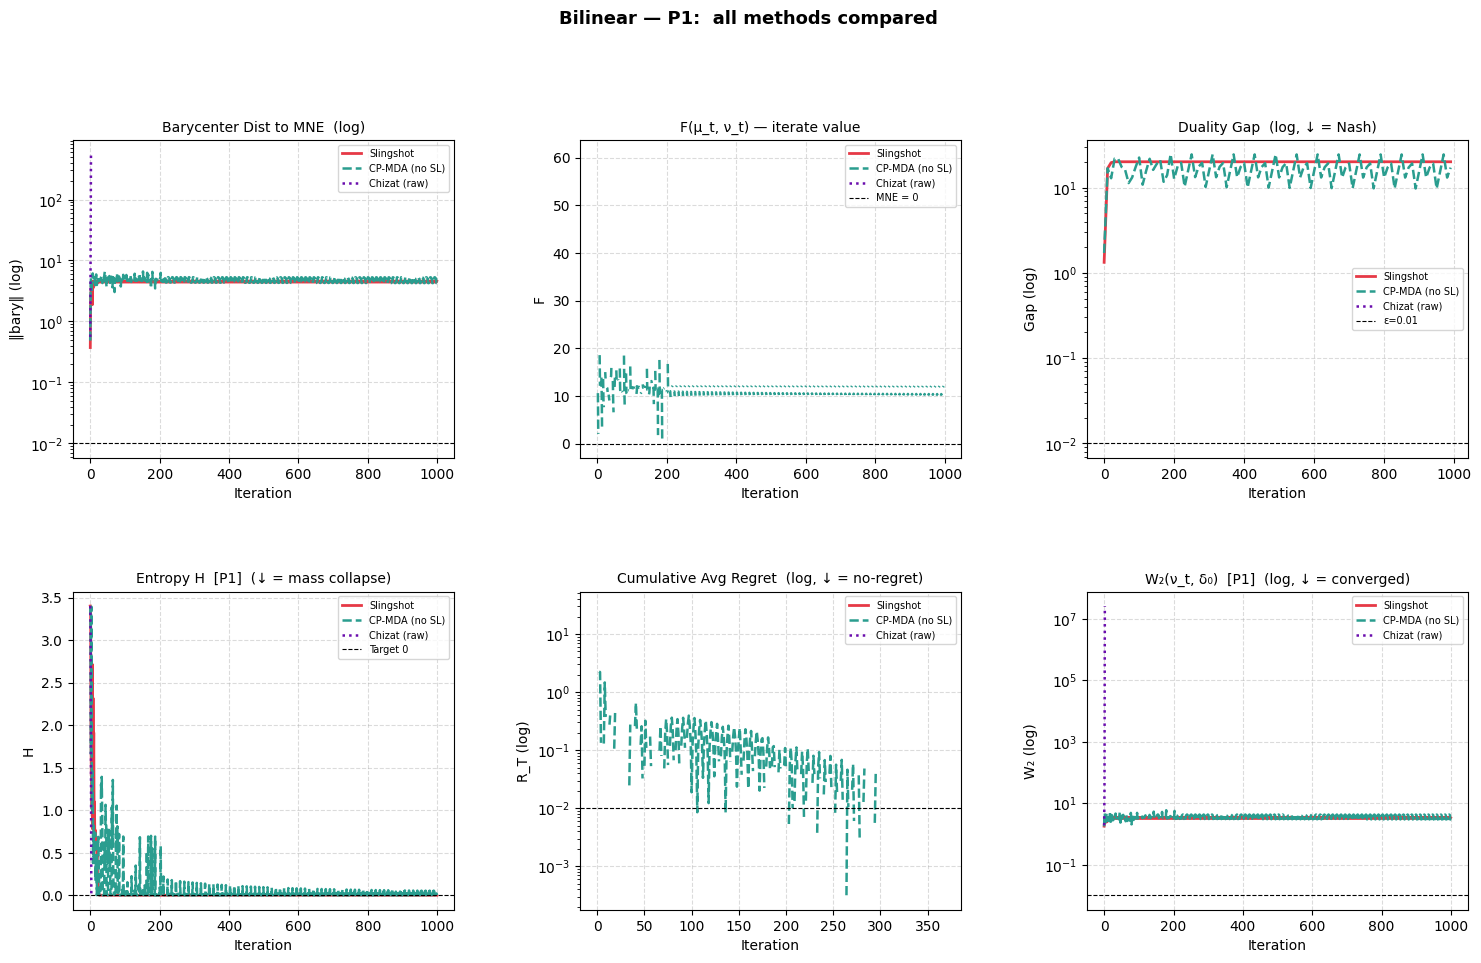

  Saved → cpmda_compare_bilinear_P2.png


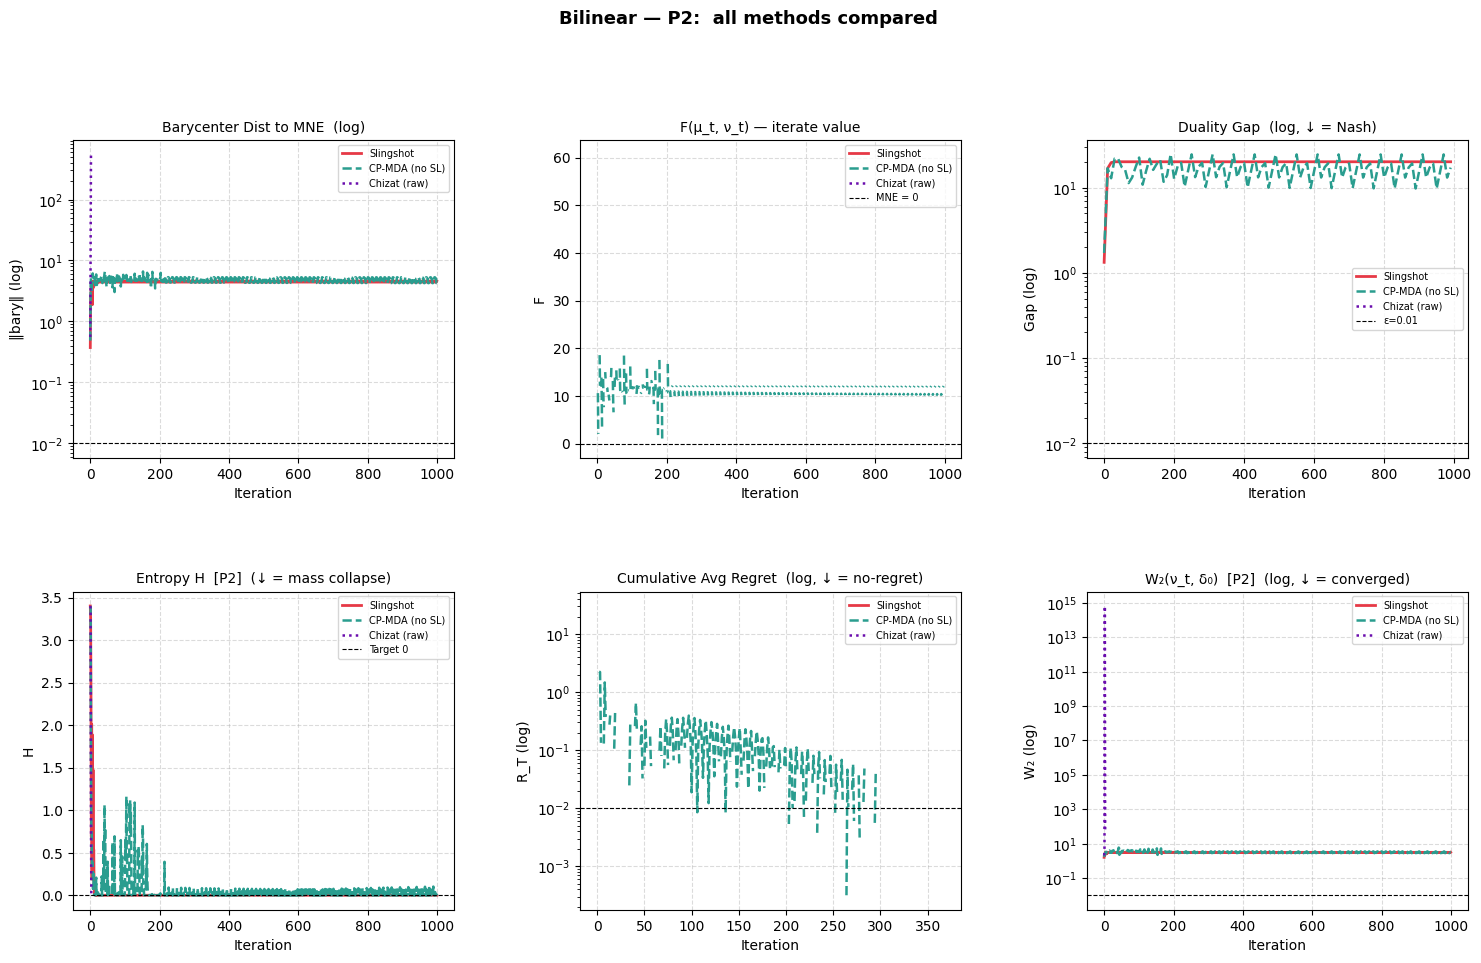

  Saved → cpmda_compare_convex_concave_P1.png


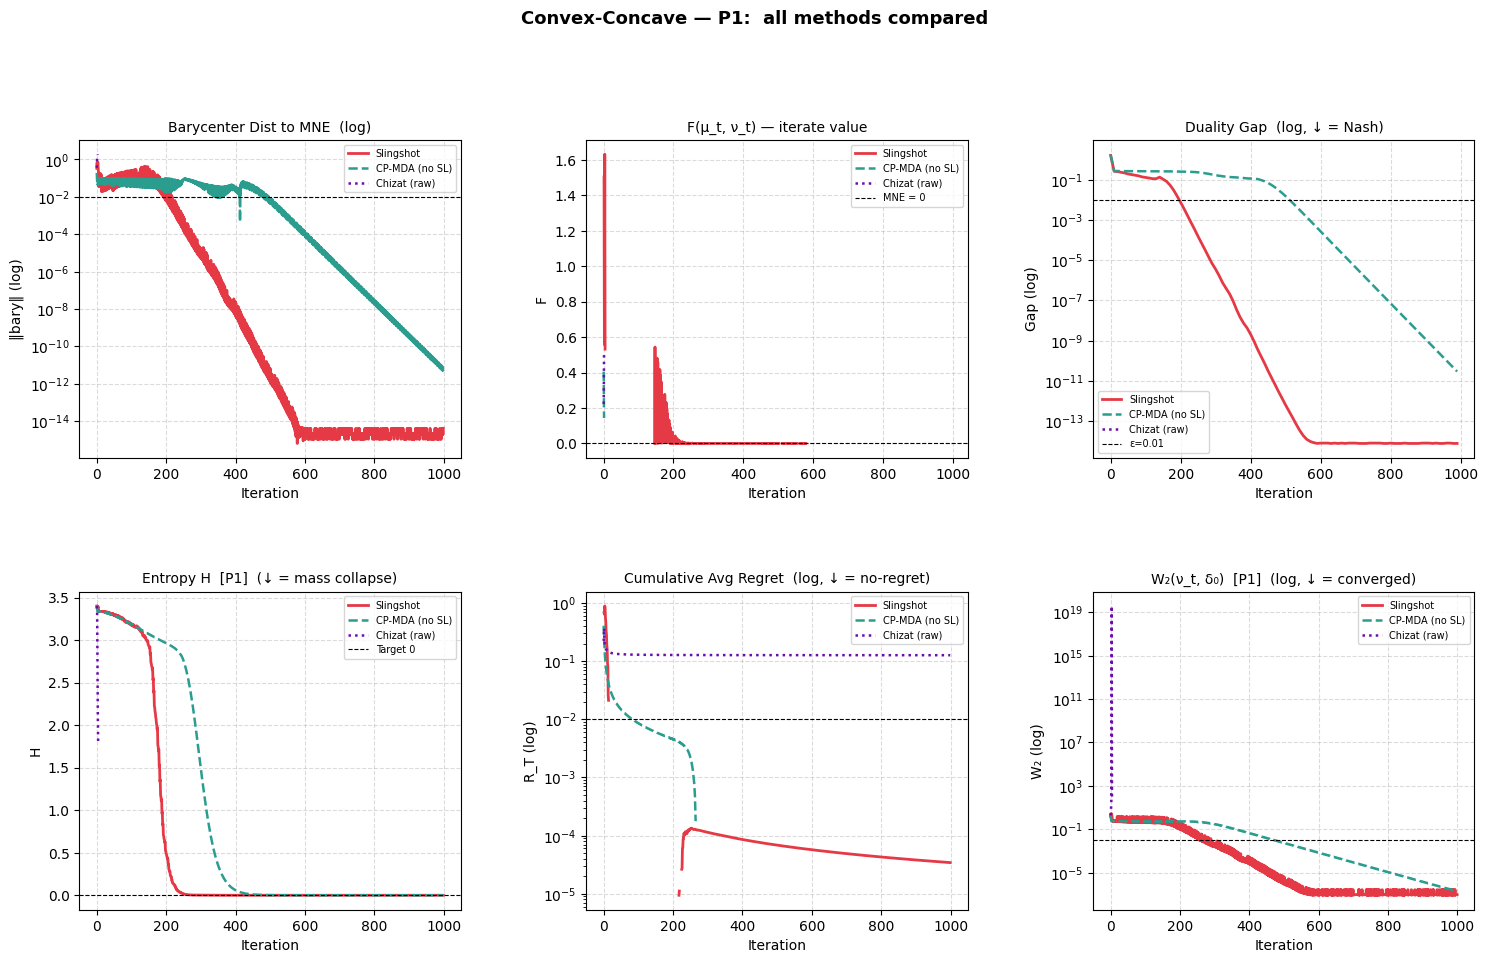

  Saved → cpmda_compare_convex_concave_P2.png


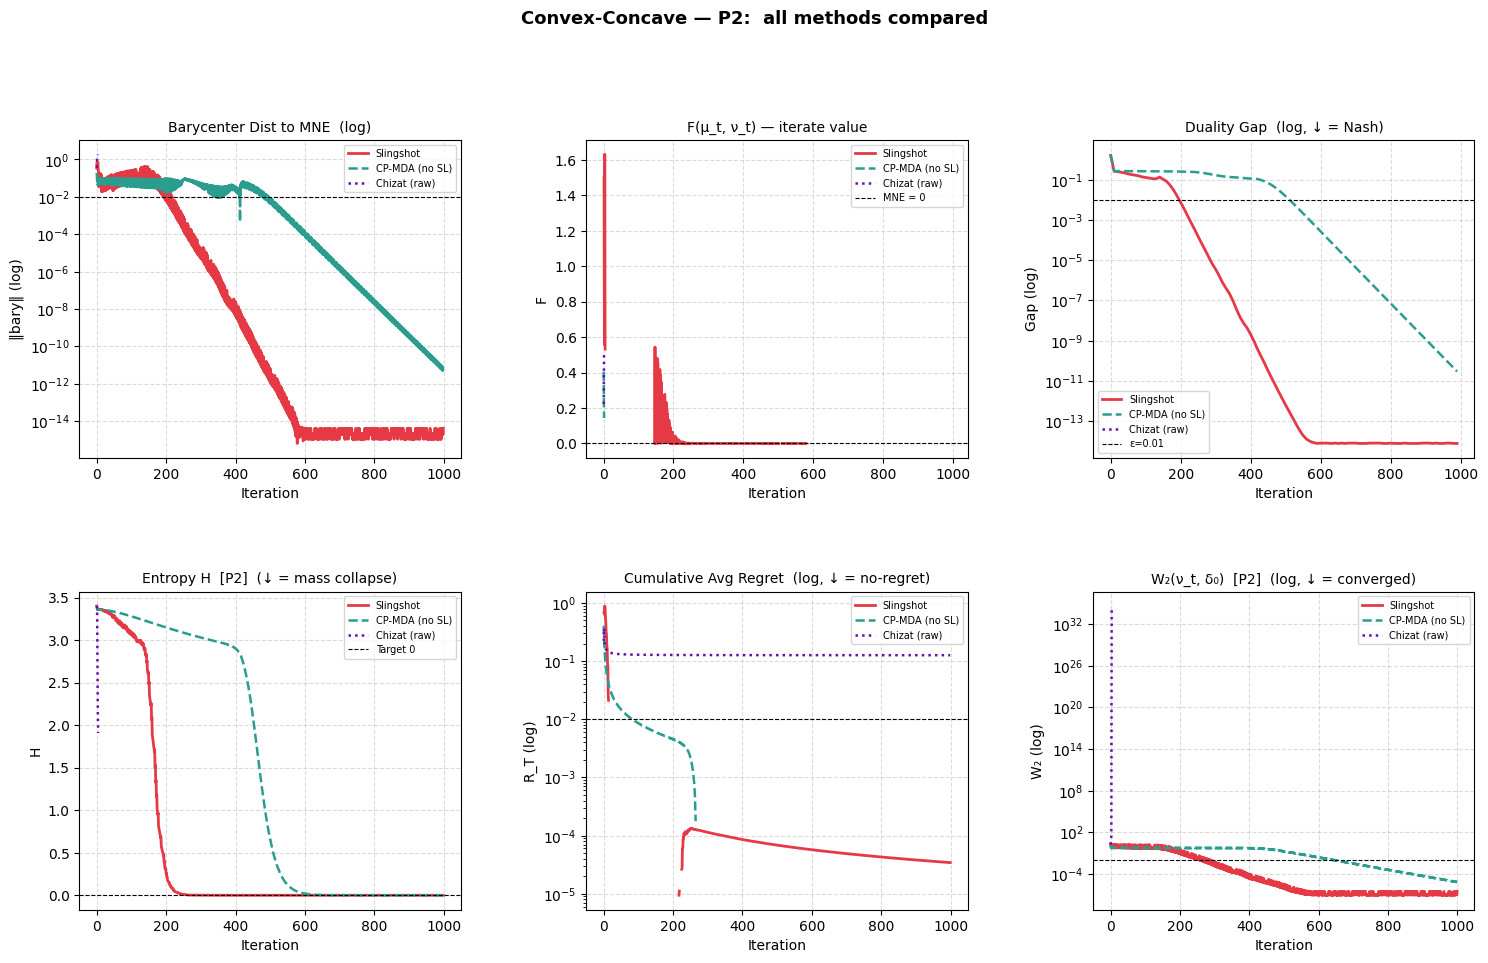

  Saved → cpmda_compare_scsc_P1.png


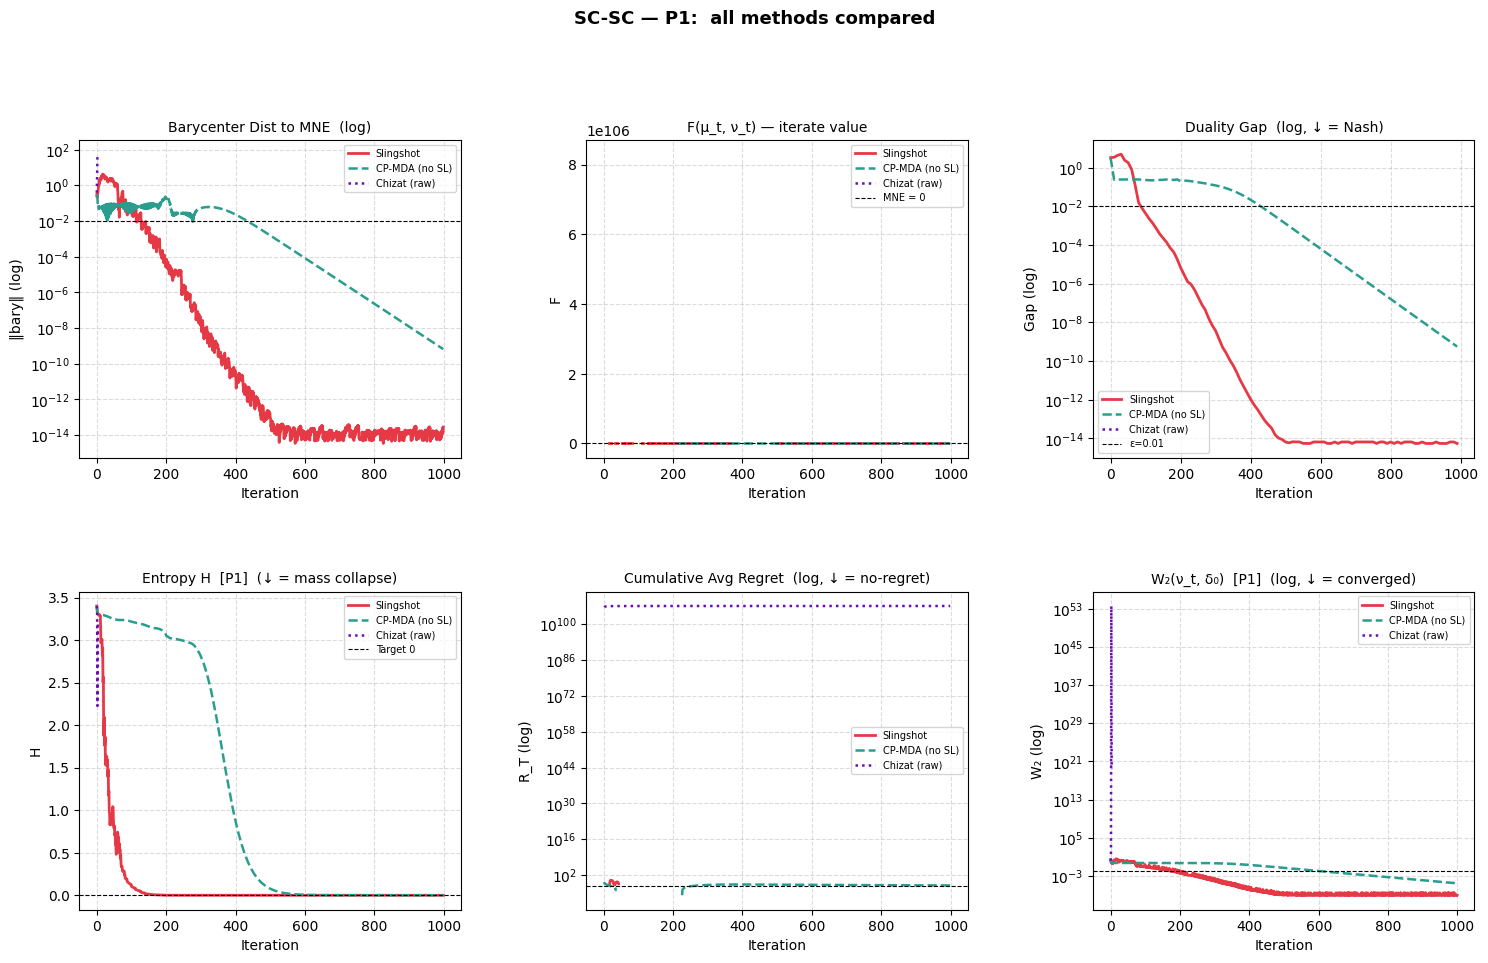

  Saved → cpmda_compare_scsc_P2.png


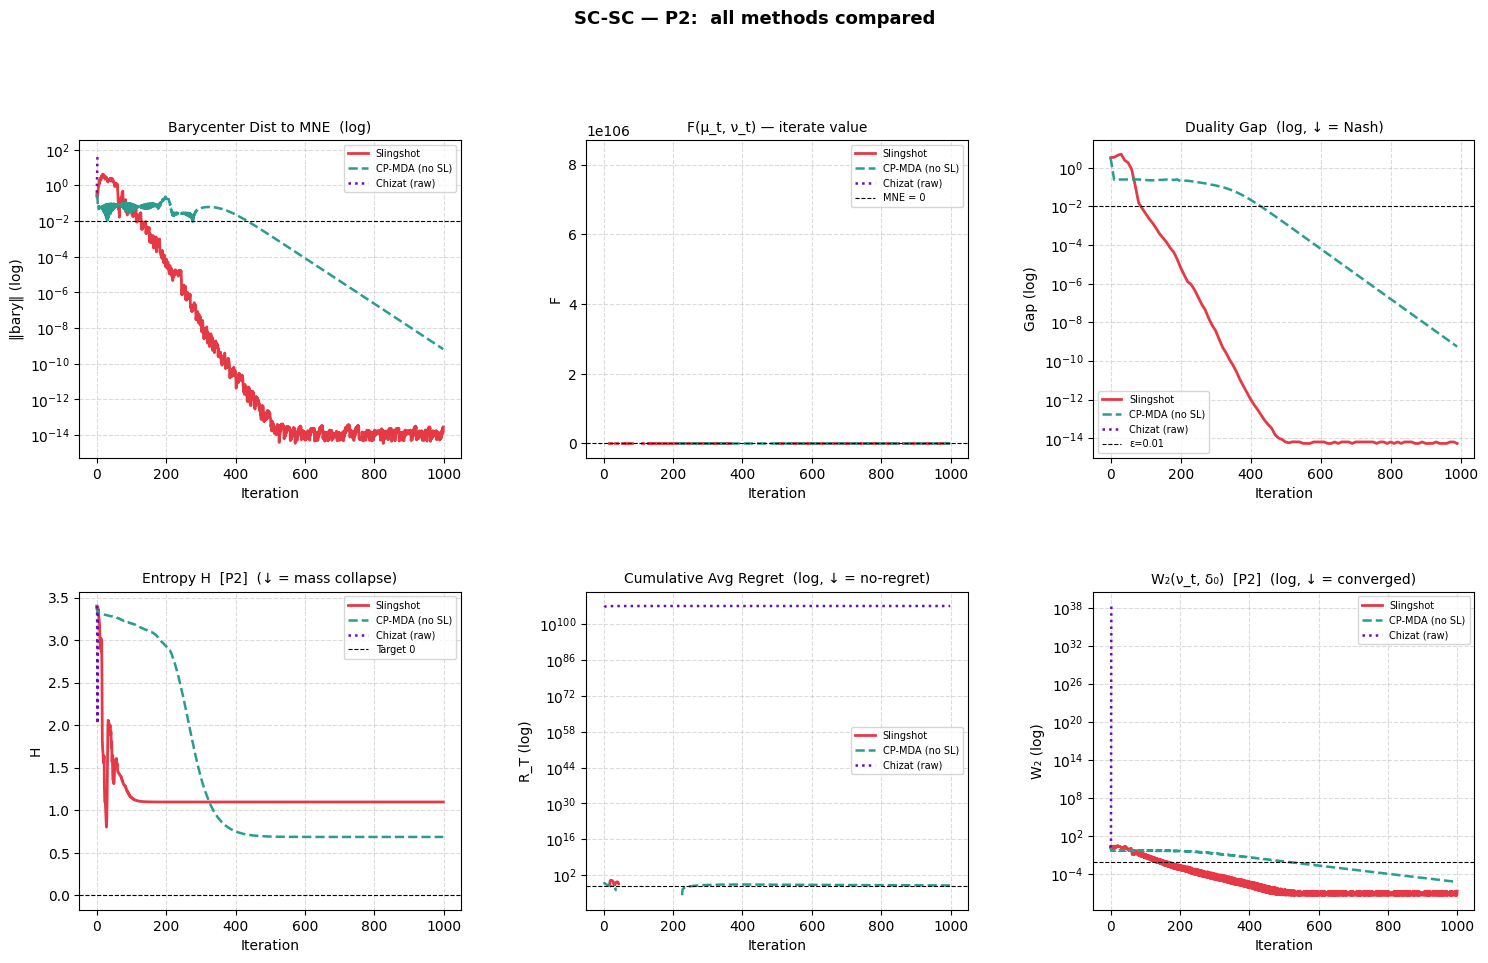

In [10]:
# ============================================================
# CELL 7 — Cross-Method Comparison Plots
# ============================================================
# Paste this cell into the notebook AFTER cells 1-3 have run
# and `histories` is populated with keys:
#   sl_{name}, off_{name}, van_{name}
#
# Produces TWO figures per game (one for P1, one for P2).
# Each figure is a 2×3 grid containing ALL six metrics:
#
#   [0,0] Barycenter distance to MNE  (log y)
#   [0,1] F(μ_t, ν_t) — iterate value (linear y)
#   [0,2] Duality gap                 (log y)
#   [1,0] Strategy entropy H          (linear y)
#   [1,1] Cumulative average regret   (log y)
#   [1,2] Wasserstein W₂ to MNE       (log y)
#
# All three methods are overlaid on each subplot so decay
# rates can be compared directly.
#
# Saved as:
#   cpmda_compare_{name}_P1.png
#   cpmda_compare_{name}_P2.png
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ------------------------------------------------------------------
# Style config — one entry per method
# ------------------------------------------------------------------
METHODS = [
    dict(key_prefix="sl",  label="Slingshot",      color="#e63946", ls="-",  lw=2.0),
    dict(key_prefix="off", label="CP-MDA (no SL)", color="#2a9d8f", ls="--", lw=1.8),
    dict(key_prefix="van", label="Chizat (raw)",   color="#6a0dad", ls=":",  lw=1.8),   # #e9c46a
]

CASES = [
    dict(name="bilinear",       label="Bilinear"),
    dict(name="convex_concave", label="Convex-Concave"),
    dict(name="scsc",           label="SC-SC"),
]


def _safe(arr):
    a = np.array(arr, dtype=float)
    a[~np.isfinite(a)] = np.nan
    a[a <= 0] = np.nan        # semilogy needs strictly positive values
    return a


def plot_comparison(histories, cases=CASES, methods=METHODS,
                    save_prefix="cpmda_compare",
                    ylims=None):
    """
        [Depreciated] ylims : dict, optional
        Keys match axis names, values are (ymin, ymax) tuples.
        Valid keys:
          'bary', 'f', 'gap', 'ent', 'reg', 'w2'
        Example:
          ylims = {
              'bary': (1e-4, 10),
              'gap' : (1e-3, 5),
              'w2'  : (1e-3, 3),
              'ent' : (0, 4),
              'f'   : (-1, 1),
              'reg' : (1e-4, 2),
          }

    For each game in `cases`, produce two figures:
      {save_prefix}_{name}_P1.png  and  {save_prefix}_{name}_P2.png

    Each figure — 2×3 grid, all six metrics:
      [0,0] Barycenter dist to origin (log)  — shared between P1/P2
      [0,1] F(μ_t, ν_t)              (linear) — shared
      [0,2] Duality gap              (log)    — shared
      [1,0] Entropy H(a) or H(b)    (linear)  — player-specific
      [1,1] Cumulative avg regret   (log)    — shared
      [1,2] W₂(μ_t,δ₀) or W₂(ν_t,δ₀)(log)  — player-specific

    Parameters
    ----------
    histories : dict
        Keys of the form  "{prefix}_{name}"  where prefix ∈ {sl, off, van}.
        Values are (history_dict, grad_func) tuples as stored by the driver.
    """
    for c in cases:
        for player, plabel in [("a", "P1"), ("b", "P2")]:

            fig = plt.figure(figsize=(18, 10))
            fig.suptitle(
                f"{c['label']} — {plabel}:  all methods compared",
                fontsize=13, fontweight='bold', y=1.01
            )
            gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.33)

            ax_bary = fig.add_subplot(gs[0, 0])   # [0,0] barycenter dist
            ax_f    = fig.add_subplot(gs[0, 1])   # [0,1] F(μ,ν)
            ax_gap  = fig.add_subplot(gs[0, 2])   # [0,2] duality gap
            ax_ent  = fig.add_subplot(gs[1, 0])   # [1,0] entropy (player-specific)
            ax_reg  = fig.add_subplot(gs[1, 1])   # [1,1] regret
            ax_w2   = fig.add_subplot(gs[1, 2])   # [1,2] wasserstein (player-specific)

            any_plotted = False

            for m in methods:
                key = f"{m['key_prefix']}_{c['name']}"
                if key not in histories:
                    continue
                h, _ = histories[key]
                any_plotted = True

                T     = len(h['a'])
                iters = np.arange(T)

                kw = dict(color=m['color'], ls=m['ls'], lw=m['lw'], label=m['label'])

                # ---- [0,0] Barycenter distance to origin ----
                traj = np.array(h['barycenter'])
                mask = ~np.isnan(traj).any(axis=1)
                tc   = traj[mask]
                if len(tc):
                    dist = _safe(np.sqrt(tc[:, 0]**2 + tc[:, 1]**2))
                    ax_bary.semilogy(np.where(mask)[0][:len(dist)], dist, **kw)

                # ---- [0,1] F(μ_t, ν_t) ----
                fv = _safe(h['f_val'])
                ax_f.plot(iters[:len(fv)], fv, **kw)

                # ---- [0,2] Duality gap ----
                gap = _safe(h['gap'])
                vi  = np.isfinite(gap)
                if vi.any():
                    ax_gap.semilogy(iters[:len(gap)][vi], gap[vi], **kw)

                # ---- [1,0] Entropy — player-specific ----
                ent = _safe(h[f'entropy_{player}'])
                ax_ent.plot(iters[:len(ent)], ent, **kw)

                # ---- [1,1] Cumulative average regret ----
                reg = _safe(h['regret'])
                ax_reg.semilogy(iters[:len(reg)], reg, **kw)

                # ---- [1,2] Wasserstein — player-specific ----
                w2 = _safe(h[f'w2_{player}'])
                ax_w2.semilogy(iters[:len(w2)], w2, **kw)

            if not any_plotted:
                plt.close(fig)
                print(f"  Skipping {c['label']} {plabel} — no histories found.")
                continue

            # # Autoscale all log axes BEFORE applying any manual ylims so that
            # # the Chizat raw line (which can be orders of magnitude larger than
            # # the slingshot lines) is always included in the visible range.
            # for ax in (ax_bary, ax_gap, ax_reg, ax_w2, ax_ent, ax_f):
            #     ax.autoscale(enable=True, axis='y')

            # ---- Axis formatting ----
            ax_bary.set_title("Barycenter Dist to MNE  (log)", fontsize=10)
            ax_bary.set_xlabel("Iteration"); ax_bary.set_ylabel("‖bary‖ (log)")
            ax_bary.legend(fontsize=7); ax_bary.grid(True, ls='--', alpha=0.45)
            ax_bary.axhline(1e-2, color='k', ls='--', lw=0.8, label='MNE = 0')

            ax_f.set_title("F(μ_t, ν_t) — iterate value", fontsize=10)
            ax_f.set_xlabel("Iteration"); ax_f.set_ylabel("F")
            ax_f.axhline(0, color='k', ls='--', lw=0.8, label='MNE = 0')
            ax_f.legend(fontsize=7); ax_f.grid(True, ls='--', alpha=0.45)

            ax_gap.set_title("Duality Gap  (log, ↓ = Nash)", fontsize=10)
            ax_gap.set_xlabel("Iteration"); ax_gap.set_ylabel("Gap (log)")
            ax_gap.axhline(1e-2, color='k', ls='--', lw=0.8, label='ε=0.01')
            ax_gap.legend(fontsize=7); ax_gap.grid(True, ls='--', alpha=0.45)

            ax_ent.set_title(f"Entropy H  [{plabel}]  (↓ = mass collapse)", fontsize=10)
            ax_ent.set_xlabel("Iteration"); ax_ent.set_ylabel("H")
            ax_ent.axhline(0, color='k', ls='--', lw=0.8, label='Target 0')
            ax_ent.legend(fontsize=7); ax_ent.grid(True, ls='--', alpha=0.45)

            ax_reg.set_title("Cumulative Avg Regret  (log, ↓ = no-regret)", fontsize=10)
            ax_reg.set_xlabel("Iteration"); ax_reg.set_ylabel("R_T (log)")
            ax_reg.legend(fontsize=7); ax_reg.grid(True, ls='--', alpha=0.45)
            ax_reg.axhline(1e-2, color='k', ls='--', lw=0.8, label='ε=0.01')

            ax_w2.set_title(f"W₂(ν_t, δ₀)  [{plabel}]  (log, ↓ = converged)", fontsize=10)
            ax_w2.set_xlabel("Iteration"); ax_w2.set_ylabel("W₂ (log)")
            ax_w2.legend(fontsize=7); ax_w2.grid(True, ls='--', alpha=0.45)
            ax_w2.axhline(1e-2, color='k', ls='--', lw=0.8, label='ε=0.01')

            # if 'ylims' not in locals(): ylims = {}

            # if 'bary' in ylims: ax_bary.set_ylim(ylims['bary'])
            # if 'f'    in ylims: ax_f.set_ylim(ylims['f'])
            # if 'gap'  in ylims: ax_gap.set_ylim(ylims['gap'])
            # if 'ent'  in ylims: ax_ent.set_ylim(ylims['ent'])
            # if 'reg'  in ylims: ax_reg.set_ylim(ylims['reg'])
            # if 'w2'   in ylims: ax_w2.set_ylim(ylims['w2'])

            plt.tight_layout()

            save_path = f"{save_prefix}_{c['name']}_{plabel}.png"
            fig.savefig(save_path, dpi=120, bbox_inches='tight')
            print(f"  Saved → {save_path}")
            plt.show()
            plt.close(fig)

# ------------------------------------------------------------------
# Run
# ------------------------------------------------------------------
plot_comparison(histories, save_prefix="cpmda_compare", ylims = {})
          #       ylims ={'bary': (1e-4, 10),
          #               'gap' : (1e-3, 5),
          #               'w2'  : (1e-3, 3),
          #               'ent' : (0, 4),
          #               'f'   : (-1, 1),
          #               'reg' : (1e-4, 2),
          # })

/tmp/ipykernel_4162/981237787.py:168: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  Saved → cpmda_compare_bilinear_P1_unabridged.png


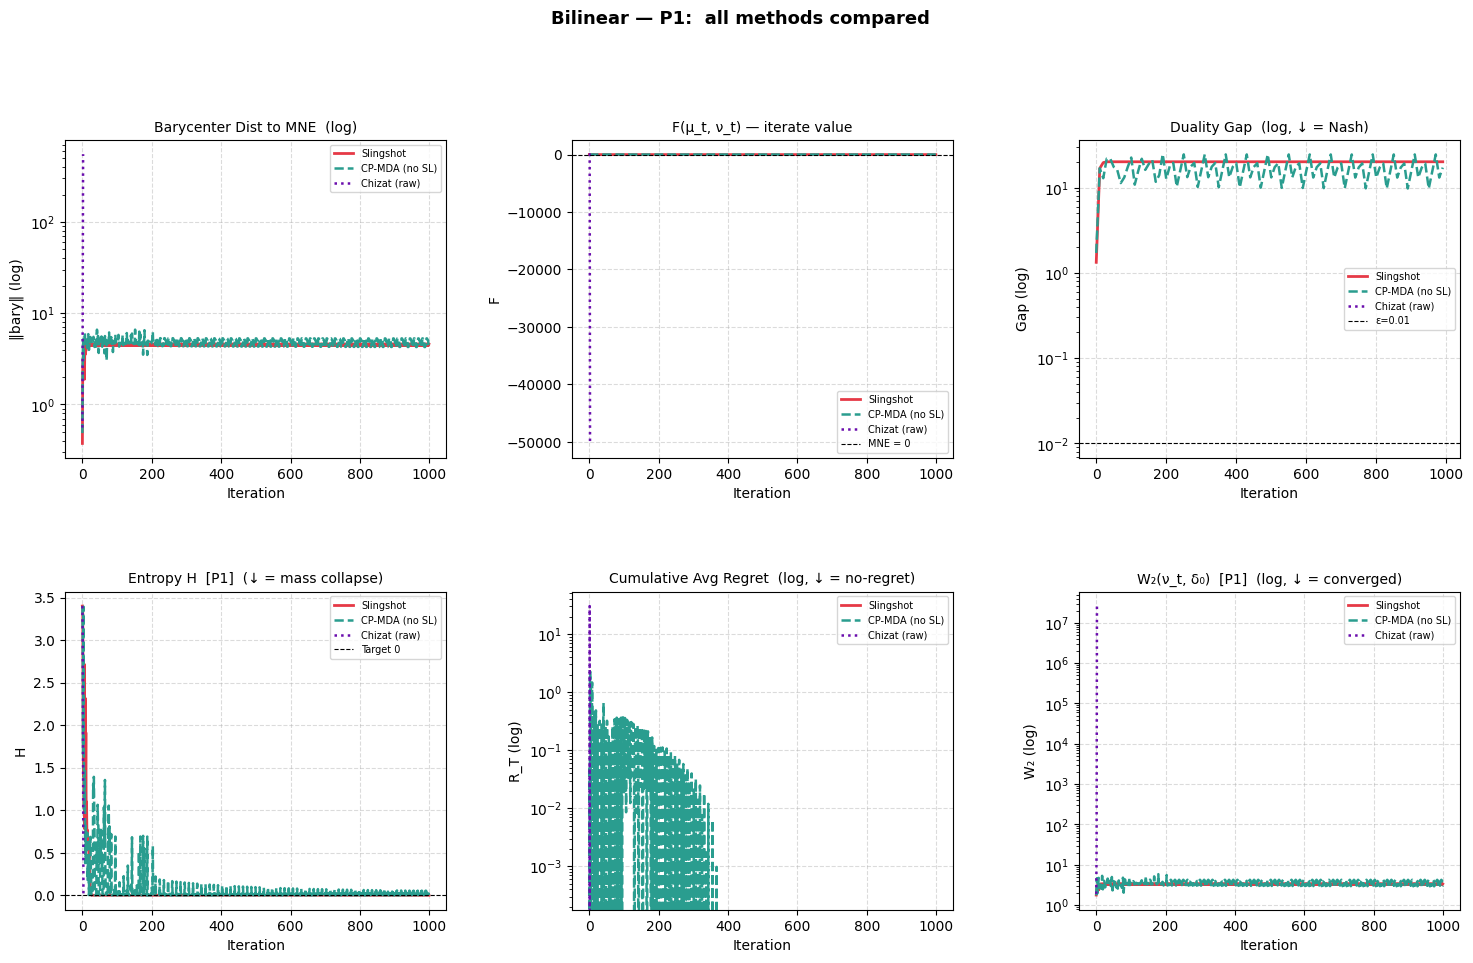

  Saved → cpmda_compare_bilinear_P2_unabridged.png


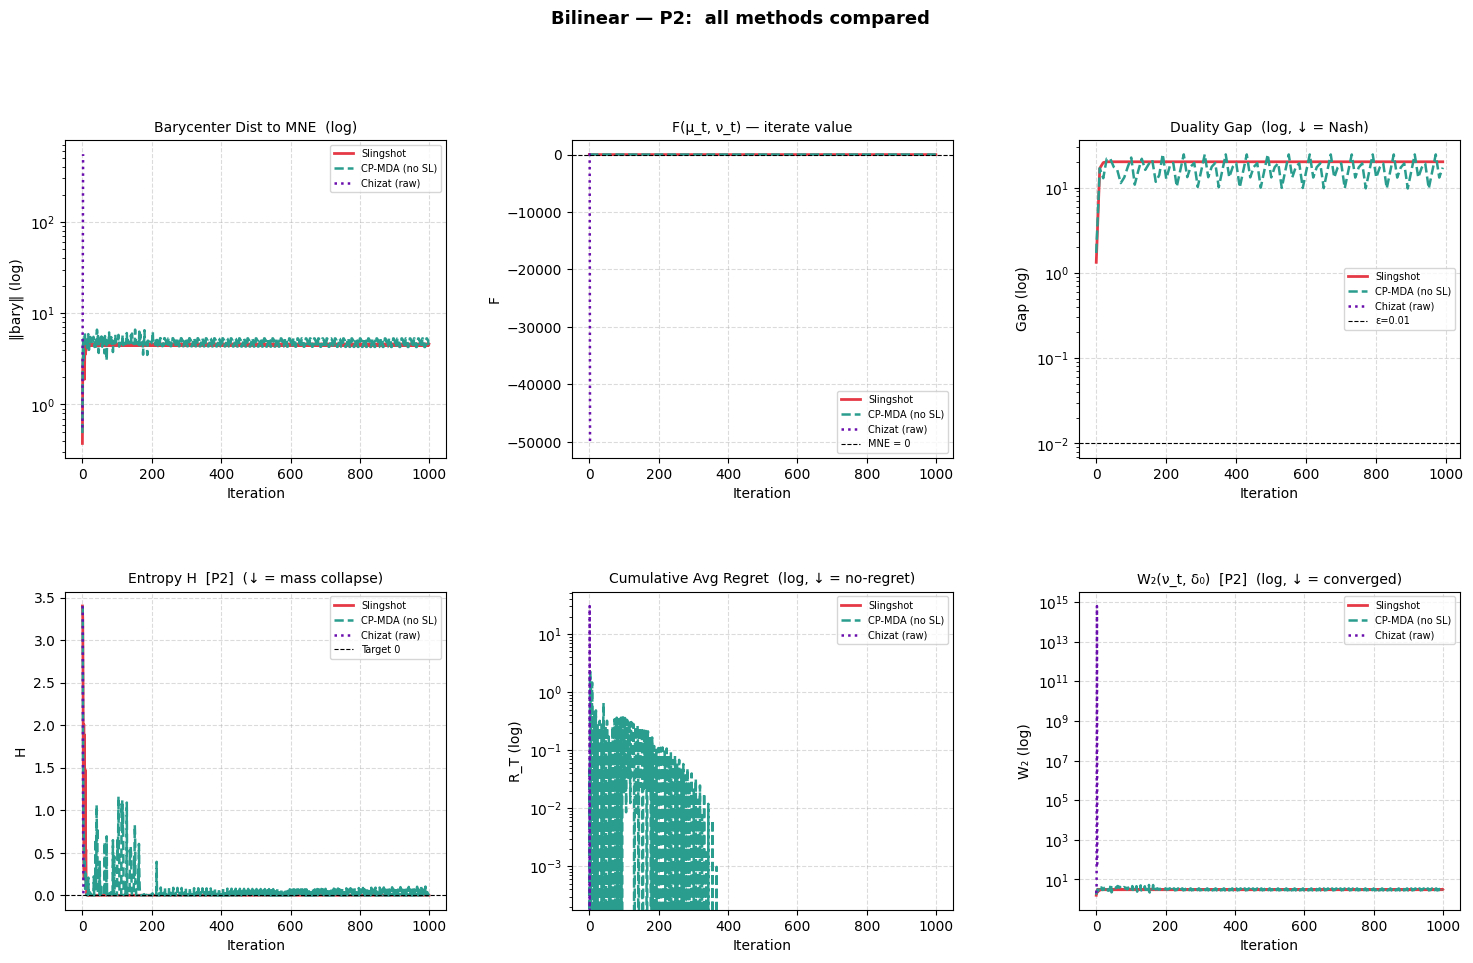

  Saved → cpmda_compare_convex_concave_P1_unabridged.png


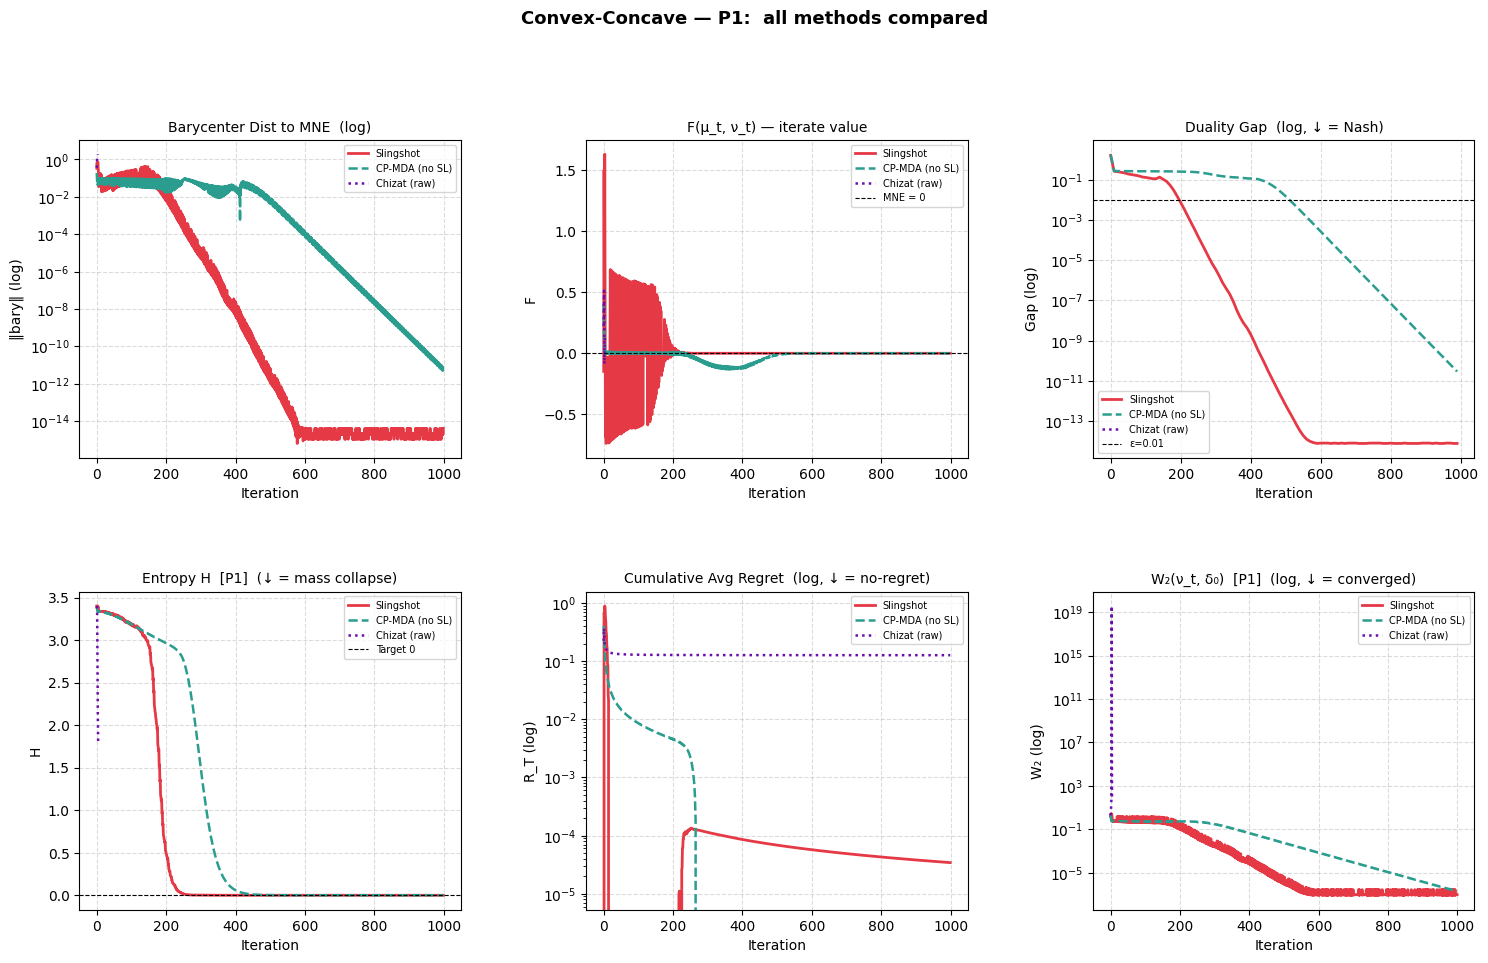

  Saved → cpmda_compare_convex_concave_P2_unabridged.png


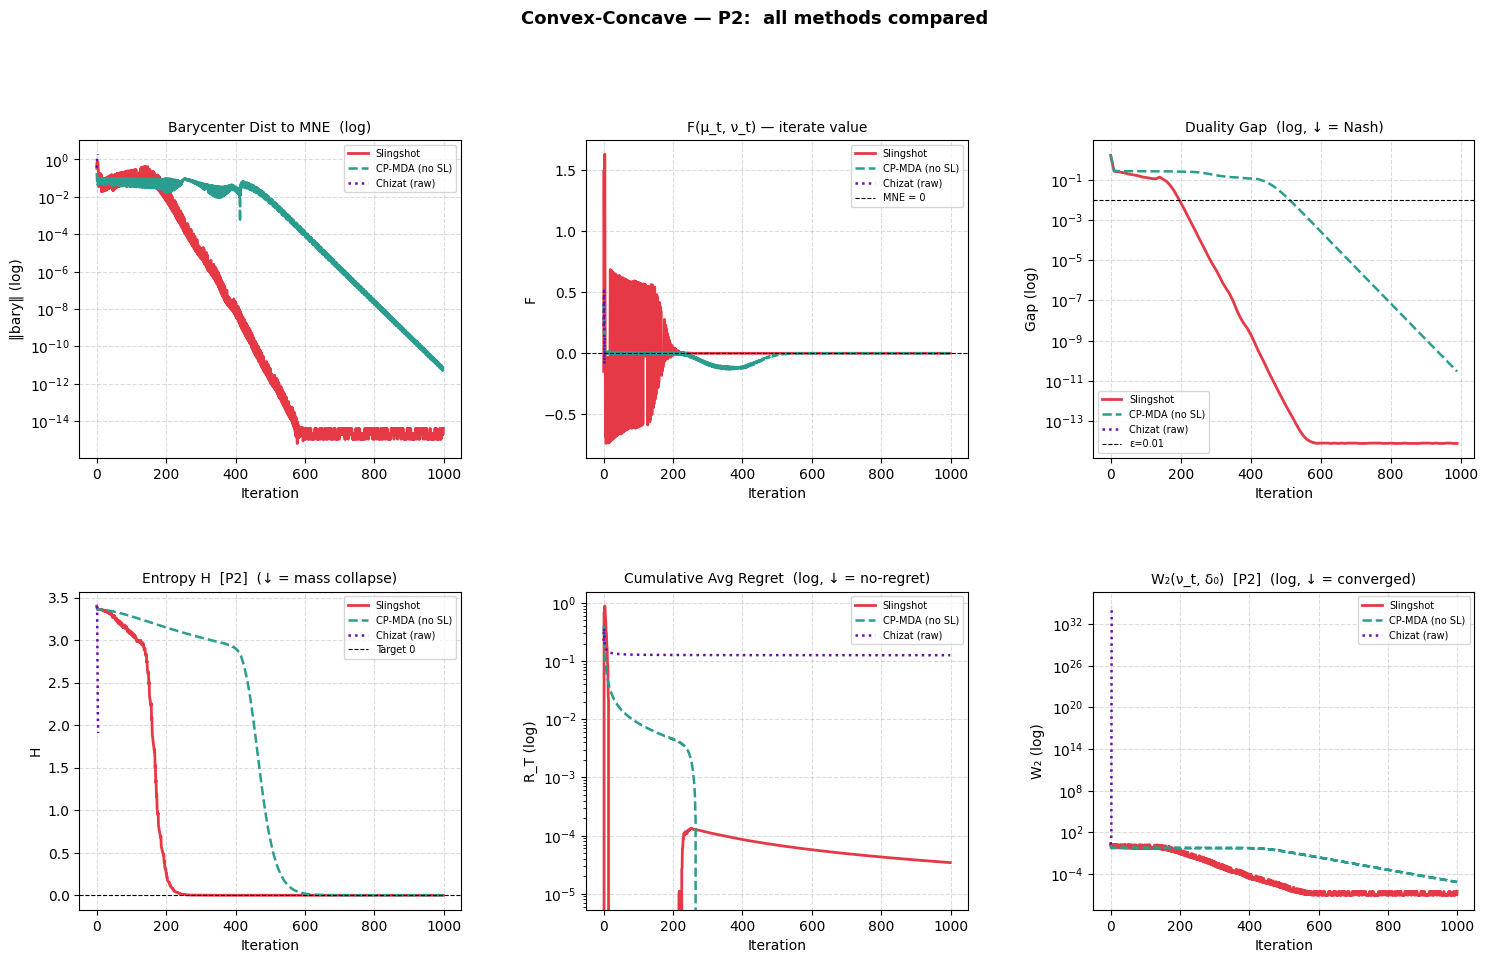

  Saved → cpmda_compare_scsc_P1_unabridged.png


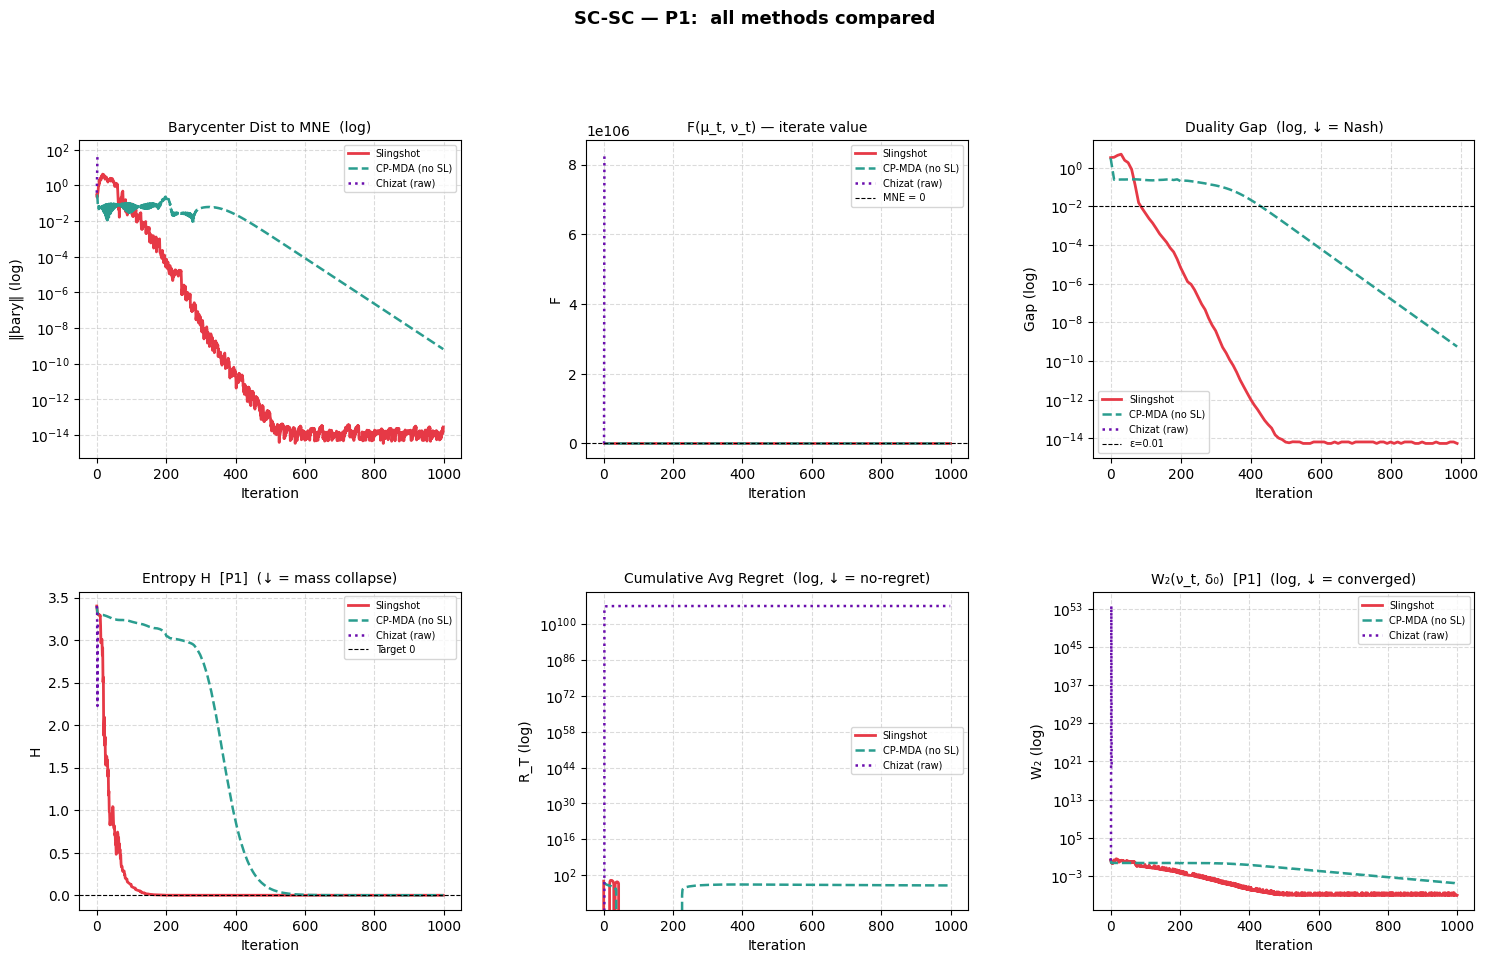

  Saved → cpmda_compare_scsc_P2_unabridged.png


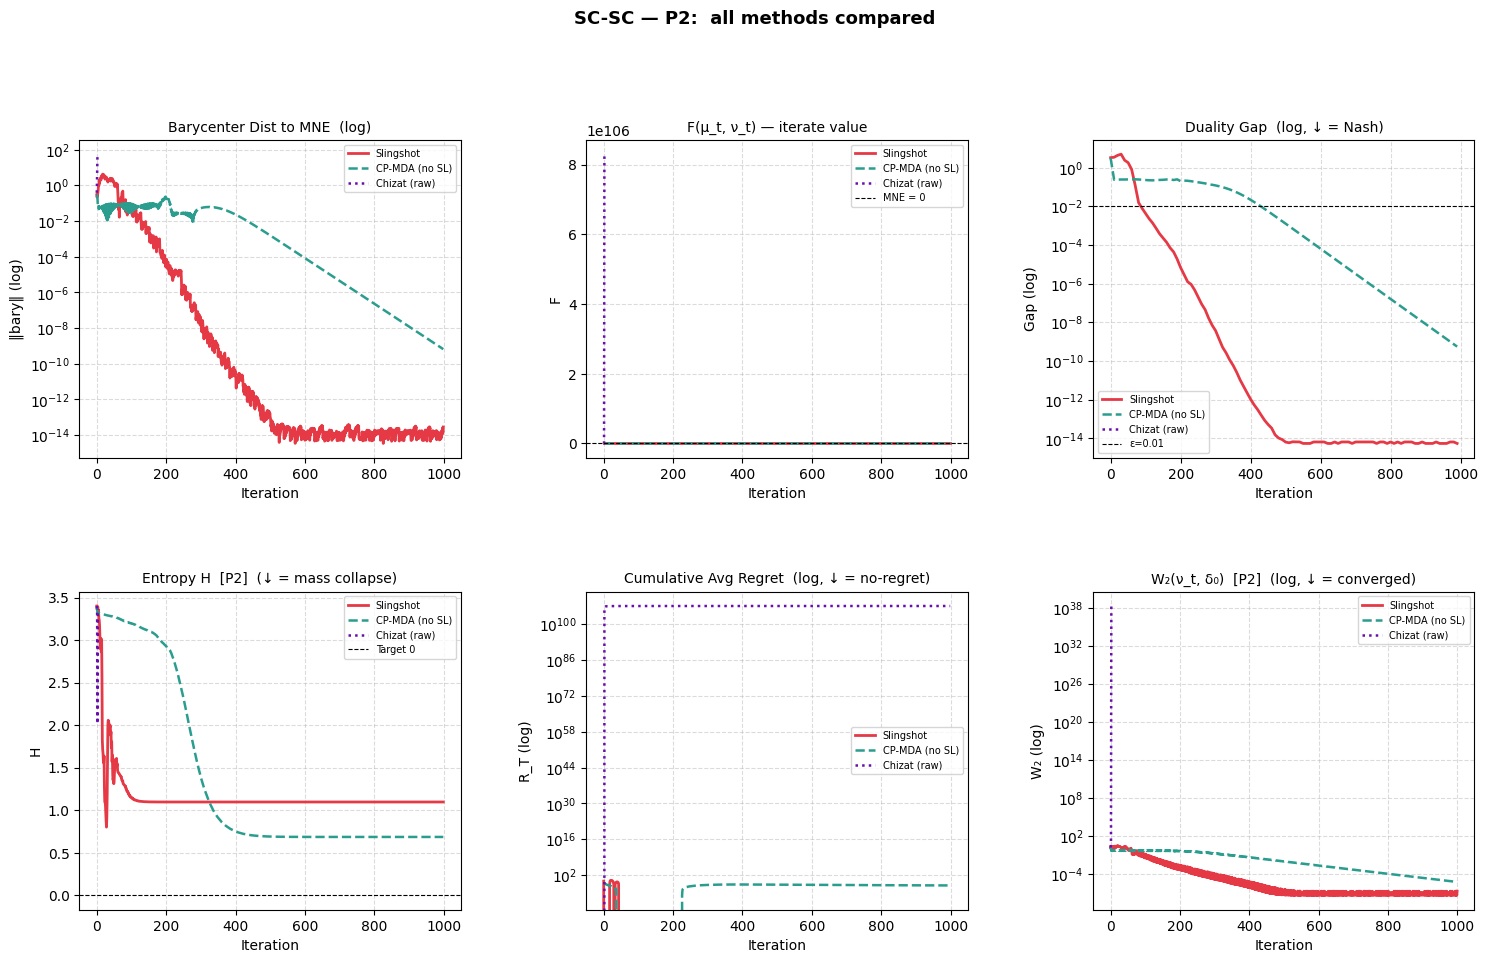

In [14]:
# ============================================================
# CELL 7 — Cross-Method Comparison Plots
# ============================================================
# Paste this cell into the notebook AFTER cells 1-3 have run
# and `histories` is populated with keys:
#   sl_{name}, off_{name}, van_{name}
#
# Produces TWO figures per game (one for P1, one for P2).
# Each figure is a 2×3 grid containing ALL six metrics:
#
#   [0,0] Barycenter distance to MNE  (log y)
#   [0,1] F(μ_t, ν_t) — iterate value (linear y)
#   [0,2] Duality gap                 (log y)
#   [1,0] Strategy entropy H          (linear y)
#   [1,1] Cumulative average regret   (log y)
#   [1,2] Wasserstein W₂ to MNE       (log y)
#
# All three methods are overlaid on each subplot so decay
# rates can be compared directly.
#
# Saved as:
#   cpmda_compare_{name}_P1.png
#   cpmda_compare_{name}_P2.png
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ------------------------------------------------------------------
# Style config — one entry per method
# ------------------------------------------------------------------
METHODS = [
    dict(key_prefix="sl",  label="Slingshot",      color="#e63946", ls="-",  lw=2.0),
    dict(key_prefix="off", label="CP-MDA (no SL)", color="#2a9d8f", ls="--", lw=1.8),
    dict(key_prefix="van", label="Chizat (raw)",   color="#6a0dad", ls=":",  lw=1.8),   # #e9c46a
]

CASES = [
    dict(name="bilinear",       label="Bilinear"),
    dict(name="convex_concave", label="Convex-Concave"),
    dict(name="scsc",           label="SC-SC"),
]


def _safe(arr):
    """Replace NaN / Inf with NaN for clean semilogy plotting."""
    a = np.array(arr, dtype=float)
    a[~np.isfinite(a)] = np.nan
    return a


def plot_comparison(histories, cases=CASES, methods=METHODS,
                    save_prefix="cpmda_compare",
                    ylims=None):
    """
    For each game in `cases`, produce two figures:
      {save_prefix}_{name}_P1.png  and  {save_prefix}_{name}_P2.png

    Each figure — 2×3 grid, all six metrics:
      [0,0] Barycenter dist to origin (log)  — shared between P1/P2
      [0,1] F(μ_t, ν_t)              (linear) — shared
      [0,2] Duality gap              (log)    — shared
      [1,0] Entropy H(a) or H(b)    (linear)  — player-specific
      [1,1] Cumulative avg regret   (log)    — shared
      [1,2] W₂(μ_t,δ₀) or W₂(ν_t,δ₀)(log)  — player-specific

    Parameters
    ----------
    histories : dict
        Keys of the form  "{prefix}_{name}"  where prefix ∈ {sl, off, van}.
        Values are (history_dict, grad_func) tuples as stored by the driver.
    """
    for c in cases:
        for player, plabel in [("a", "P1"), ("b", "P2")]:

            fig = plt.figure(figsize=(18, 10))
            fig.suptitle(
                f"{c['label']} — {plabel}:  all methods compared",
                fontsize=13, fontweight='bold', y=1.01
            )
            gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.33)

            ax_bary = fig.add_subplot(gs[0, 0])   # [0,0] barycenter dist
            ax_f    = fig.add_subplot(gs[0, 1])   # [0,1] F(μ,ν)
            ax_gap  = fig.add_subplot(gs[0, 2])   # [0,2] duality gap
            ax_ent  = fig.add_subplot(gs[1, 0])   # [1,0] entropy (player-specific)
            ax_reg  = fig.add_subplot(gs[1, 1])   # [1,1] regret
            ax_w2   = fig.add_subplot(gs[1, 2])   # [1,2] wasserstein (player-specific)

            any_plotted = False

            for m in methods:
                key = f"{m['key_prefix']}_{c['name']}"
                if key not in histories:
                    continue
                h, _ = histories[key]
                any_plotted = True

                T     = len(h['a'])
                iters = np.arange(T)

                kw = dict(color=m['color'], ls=m['ls'], lw=m['lw'], label=m['label'])

                # ---- [0,0] Barycenter distance to origin ----
                traj = np.array(h['barycenter'])
                mask = ~np.isnan(traj).any(axis=1)
                tc   = traj[mask]
                if len(tc):
                    dist = _safe(np.sqrt(tc[:, 0]**2 + tc[:, 1]**2))
                    ax_bary.semilogy(np.where(mask)[0][:len(dist)], dist, **kw)

                # ---- [0,1] F(μ_t, ν_t) ----
                fv = _safe(h['f_val'])
                ax_f.plot(iters[:len(fv)], fv, **kw)

                # ---- [0,2] Duality gap ----
                gap = _safe(h['gap'])
                vi  = np.isfinite(gap)
                if vi.any():
                    ax_gap.semilogy(iters[:len(gap)][vi], gap[vi], **kw)

                # ---- [1,0] Entropy — player-specific ----
                ent = _safe(h[f'entropy_{player}'])
                ax_ent.plot(iters[:len(ent)], ent, **kw)

                # ---- [1,1] Cumulative average regret ----
                reg = _safe(h['regret'])
                ax_reg.semilogy(iters[:len(reg)], reg, **kw)

                # ---- [1,2] Wasserstein — player-specific ----
                w2 = _safe(h[f'w2_{player}'])
                ax_w2.semilogy(iters[:len(w2)], w2, **kw)

            if not any_plotted:
                plt.close(fig)
                print(f"  Skipping {c['label']} {plabel} — no histories found.")
                continue

            # ---- Axis formatting ----
            ax_bary.set_title("Barycenter Dist to MNE  (log)", fontsize=10)
            ax_bary.set_xlabel("Iteration"); ax_bary.set_ylabel("‖bary‖ (log)")
            ax_bary.legend(fontsize=7); ax_bary.grid(True, ls='--', alpha=0.45)

            ax_f.set_title("F(μ_t, ν_t) — iterate value", fontsize=10)
            ax_f.set_xlabel("Iteration"); ax_f.set_ylabel("F")
            ax_f.axhline(0, color='k', ls='--', lw=0.8, label='MNE = 0')
            ax_f.legend(fontsize=7); ax_f.grid(True, ls='--', alpha=0.45)

            ax_gap.set_title("Duality Gap  (log, ↓ = Nash)", fontsize=10)
            ax_gap.set_xlabel("Iteration"); ax_gap.set_ylabel("Gap (log)")
            ax_gap.axhline(1e-2, color='k', ls='--', lw=0.8, label='ε=0.01')
            ax_gap.legend(fontsize=7); ax_gap.grid(True, ls='--', alpha=0.45)

            ax_ent.set_title(f"Entropy H  [{plabel}]  (↓ = mass collapse)", fontsize=10)
            ax_ent.set_xlabel("Iteration"); ax_ent.set_ylabel("H")
            ax_ent.axhline(0, color='k', ls='--', lw=0.8, label='Target 0')
            ax_ent.legend(fontsize=7); ax_ent.grid(True, ls='--', alpha=0.45)

            ax_reg.set_title("Cumulative Avg Regret  (log, ↓ = no-regret)", fontsize=10)
            ax_reg.set_xlabel("Iteration"); ax_reg.set_ylabel("R_T (log)")
            ax_reg.legend(fontsize=7); ax_reg.grid(True, ls='--', alpha=0.45)

            ax_w2.set_title(f"W₂(ν_t, δ₀)  [{plabel}]  (log, ↓ = converged)", fontsize=10)
            ax_w2.set_xlabel("Iteration"); ax_w2.set_ylabel("W₂ (log)")
            ax_w2.legend(fontsize=7); ax_w2.grid(True, ls='--', alpha=0.45)

            plt.tight_layout()

            save_path = f"{save_prefix}_{c['name']}_{plabel}_unabridged.png"
            fig.savefig(save_path, dpi=120, bbox_inches='tight')
            print(f"  Saved → {save_path}")
            plt.show()
            plt.close(fig)


# ------------------------------------------------------------------
# Run
# ------------------------------------------------------------------
plot_comparison(histories, save_prefix="cpmda_compare")

In [ ]:
# cpmda_sling_fixed.py
# KEY FIXES:
# 1. Position step uses PRE-UPDATE weights (saved before weight update)
# 2. Adaptive clipping: clip is proportional to weight, so heavy particles move less
# 3. More iterations + larger particle count for better mass collapse visibility
# 4. Added a rich convergence dashboard (4-panel) with entropy, Hamiltonian, and barycenter dist

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# ==========================================
# 1. Slingshot Stepsize Scheduler
# ==========================================
def get_slingshot_steps(problem_type, t, T, L=None, m=None, M=None, rng=None):
    rng = rng or np.random.default_rng()

    if problem_type == "bilinear":
        k = t // 2
        r_t = (M + m) / 2 + (M - m) / 2 * np.cos((2 * k + 1) * np.pi / (2 * T))
        h = 1.0 / np.sqrt(r_t)
        return (h, -h) if t % 2 == 0 else (-h, h)
    else:
        h = 1.0 / (3.0 * L)
        if t % 2 == 0:
            if rng.random() < 0.5:
                return h, -h
            else:
                return -h, h
        else:
            return h, h

# ==========================================
# 2. Conic Particle MDA Algorithm
# ==========================================
class ConicParticles:
    def __init__(self, n, m, d, rng=None):
        rng = rng or np.random.default_rng()
        self.a = np.ones(n) / n
        self.x = rng.uniform(-3, 3, (n, d))
        self.b = np.ones(m) / m
        self.y = rng.uniform(-3, 3, (m, d))

    def update_mda(self, grad_a, grad_x, grad_b, grad_y, alpha, beta):
        # FIX 1: Save weights BEFORE updating them
        a_old = self.a.copy()
        b_old = self.b.copy()

        # ---- Player 1 (Descent) ----
        # Weight Update (Log-Sum-Exp Trick)
        log_a = np.log(np.maximum(a_old, 1e-15)) - alpha * grad_a
        log_a -= np.max(log_a)
        self.a = np.exp(log_a)
        self.a /= np.sum(self.a)

        # FIX 2: Position update uses PRE-update weights (a_old), not self.a
        # FIX 3: Adaptive clipping — max step scales with weight so ghost particles
        #         can still explore but heavy particles are conservative
        denom_x = np.maximum(a_old[:, None], 1e-3)
        step_x = alpha * grad_x / denom_x
        # Clip per-particle: heavy particle (a~1/n initially) gets tighter clip
        clip_val = np.minimum(1.0, 0.1 / np.maximum(a_old[:, None], 1e-3))
        self.x -= np.clip(step_x, -clip_val, clip_val)

        # ---- Player 2 (Ascent) ----
        log_b = np.log(np.maximum(b_old, 1e-15)) + beta * grad_b
        log_b -= np.max(log_b)
        self.b = np.exp(log_b)
        self.b /= np.sum(self.b)

        denom_y = np.maximum(b_old[:, None], 1e-3)
        step_y = beta * grad_y / denom_y
        clip_val_y = np.minimum(1.0, 0.1 / np.maximum(b_old[:, None], 1e-3))
        self.y += np.clip(step_y, -clip_val_y, clip_val_y)

        M = 10.0

        self.x = np.clip(self.x, -1*M, M)
        self.y = np.clip(self.y, -1*M, M)

# ==========================================
# 3. Objective Functions & Gradients
# ==========================================
def f_bilinear(x, y, B):   return x @ B @ y
def grad_bilinear(x, y, B): return B @ y, B.T @ x

def logcosh(x):
    s = np.sign(x) * x
    p = np.exp(-2 * s)
    return s + np.log1p(p) - np.log(2.0)

def f_convex_concave(x, y):    return float(logcosh(x) - logcosh(y))
def grad_convex_concave(x, y): return np.tanh(x), -np.tanh(y)

def f_sc_sc(x, y, mu=1.0):    return float(0.5 * mu * np.sum(x**2) - 0.5 * mu * np.sum(y**2) + np.sum(x * y))
def grad_sc_sc(x, y, mu=1.0): return mu * x + y, -mu * y + x

# ==========================================
# 4. Diagnostics helpers
# ==========================================
def get_weighted_barycenter(weights, positions):
    return np.sum(weights[:, None] * positions, axis=0)

def entropy(weights):
    w = np.maximum(weights, 1e-15)
    return -np.sum(w * np.log(w))

def duality_gap(a, x, b, y, f_func):
    """
    Approximate exploitability / duality gap.
    max_j sum_i a_i f(x_i, y_j)  -  min_i sum_j b_j f(x_i, y_j)
    """
    vals = np.array([[float(f_func(x[i], y[j])) for j in range(len(y))] for i in range(len(x))])
    # P1's value against best P2 response
    v_p2_best = np.max(vals.T @ a)   # max_j  sum_i a_i f(xi, yj)
    # P2's value against best P1 response
    v_p1_best = np.min(vals @ b)     # min_i  sum_j b_j f(xi, yj)
    return v_p2_best - v_p1_best     # >= 0; zero iff MNE

# ==========================================
# 5. Experiment runner
# ==========================================
def run_experiment(model, grad_func, f_func, steps=200,
                   problem_type="bilinear", T=None, L=None, m=None, M=None,
                   rng=None):
    rng = rng or np.random.default_rng()
    T = T or steps
    history = {'a': [], 'x': [], 'b': [], 'y': [],
               'barycenter': [], 'entropy_a': [], 'entropy_b': [],
               'hamiltonian': [], 'gap': []}

    for t in range(steps):
        history['a'].append(model.a.copy())
        history['x'].append(model.x.copy())
        history['b'].append(model.b.copy())
        history['y'].append(model.y.copy())

        xb = get_weighted_barycenter(model.a, model.x)[0]
        yb = get_weighted_barycenter(model.b, model.y)[0]
        history['barycenter'].append((xb, yb))
        history['entropy_a'].append(entropy(model.a))
        history['entropy_b'].append(entropy(model.b))

        gx0, gy0 = grad_func(np.array([xb]), np.array([yb]))
        history['hamiltonian'].append(0.5 * (float(np.sum(gx0**2)) + float(np.sum(gy0**2))))

        # Duality gap every 10 steps (expensive O(n*m) call)
        if t % 10 == 0:
            history['gap'].append(duality_gap(model.a, model.x, model.b, model.y, f_func))
        else:
            history['gap'].append(np.nan)

        alpha, beta = get_slingshot_steps(problem_type, t, T, L=L, m=m, M=M, rng=rng)

        n_, m_ = model.x.shape[0], model.y.shape[0]
        grad_x = np.zeros_like(model.x)
        grad_y = np.zeros_like(model.y)
        grad_a = np.zeros(n_)
        grad_b = np.zeros(m_)

        for i in range(n_):
            for j in range(m_):
                gx, gy = grad_func(model.x[i], model.y[j])
                val = float(f_func(model.x[i], model.y[j]))
                grad_x[i] += model.b[j] * float(gx)
                grad_y[j] += model.a[i] * float(gy)
                grad_a[i] += model.b[j] * val
                grad_b[j] += model.a[i] * val

        model.update_mda(grad_a, grad_x, grad_b, grad_y, alpha, beta)

    return history

# ==========================================
# 6. Rich 4-panel static convergence dashboard
# ==========================================
def plot_dashboard(history, grad_func, title=""):
    """
    Panel 1: Hamiltonian landscape + barycenter path
    Panel 2: Log barycenter distance to origin
    Panel 3: Entropy of both players (should DROP to 0 at convergence)
    Panel 4: Duality gap (should DROP to 0 at convergence)
    """
    fig, axs = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # --- Panel 1: Landscape ---
    xs = np.linspace(-3, 3, 80)
    X, Y = np.meshgrid(xs, xs)
    Z = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            gx, gy = grad_func(np.array([X[i, j]]), np.array([Y[i, j]]))
            Z[i, j] = 0.5 * (float(np.sum(gx**2)) + float(np.sum(gy**2)))
    axs[0].contourf(X, Y, Z, levels=30, cmap='Blues', alpha=0.5)

    traj = np.array(history['barycenter'])
    mask = ~np.isnan(traj).any(axis=1)
    tc = traj[mask]
    if len(tc) > 0:
        axs[0].plot(tc[:, 0], tc[:, 1], 'k-', lw=2, label='Barycenter', zorder=3)
        axs[0].scatter(*tc[0], c='white', edgecolors='k', s=100, zorder=4, label='Start')
        axs[0].scatter(*tc[-1], c='yellow', edgecolors='k', marker='*', s=400, zorder=5, label='End')
    a_f, x_f = history['a'][-1], history['x'][-1]
    b_f, y_f = history['b'][-1], history['y'][-1]
    axs[0].scatter(x_f[:, 0], np.full(len(x_f), -0.05),
                   s=np.maximum(a_f * 2000, 5), c='red', alpha=0.8, edgecolors='k', zorder=5)
    axs[0].scatter(np.full(len(y_f), 0.05), y_f[:, 0],
                   s=np.maximum(b_f * 2000, 5), c='orange', alpha=0.8, edgecolors='k', zorder=5)
    axs[0].set_xlim(-3, 3); axs[0].set_ylim(-3, 3)
    axs[0].set_title("Hamiltonian + Particles"); axs[0].legend(fontsize=7)

    # --- Panel 2: Log barycenter distance ---
    if len(tc) > 0:
        dist = np.sqrt(tc[:, 0]**2 + tc[:, 1]**2)
        axs[1].semilogy(dist, c='purple', lw=2)
        axs[1].set_title("Barycenter Distance (log)")
        axs[1].set_xlabel("Iteration"); axs[1].set_ylabel("||bary||")
        axs[1].grid(True, ls='--', alpha=0.5)

    # --- Panel 3: Entropy ---
    # At MNE, entropy should → 0 (all mass on one particle = pure strategy)
    ea = np.array(history['entropy_a'])
    eb = np.array(history['entropy_b'])
    axs[2].plot(ea, c='red', lw=2, label='H(a) - P1')
    axs[2].plot(eb, c='orange', lw=2, label='H(b) - P2')
    axs[2].axhline(0, color='black', ls='--', lw=1, label='Target (0)')
    axs[2].set_title("Strategy Entropy (↓ = mass collapse)")
    axs[2].set_xlabel("Iteration"); axs[2].set_ylabel("Entropy")
    axs[2].legend(fontsize=8); axs[2].grid(True, ls='--', alpha=0.5)

    # --- Panel 4: Duality gap ---
    gap = np.array(history['gap'])
    valid_gap = ~np.isnan(gap)
    iters = np.where(valid_gap)[0]
    axs[3].semilogy(iters, gap[valid_gap], 'g-o', lw=2, ms=4, label='Duality Gap')
    axs[3].axhline(0.01, color='red', ls='--', lw=1, label='ε=0.01')
    axs[3].set_title("Duality Gap (↓ = Nash)")
    axs[3].set_xlabel("Iteration"); axs[3].set_ylabel("Gap (log)")
    axs[3].legend(fontsize=8); axs[3].grid(True, ls='--', alpha=0.5)

    plt.tight_layout()
    return fig

# ==========================================
# 7. GIF Generator (same as before, now includes entropy panel)
# ==========================================
def animate_convergence(history, grad_func, filename="convergence.gif", title=""):
    fig, axs = plt.subplots(1, 4, figsize=(20, 5))

    xs = np.linspace(-3, 3, 80)
    X, Y = np.meshgrid(xs, xs)
    Z = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            gx, gy = grad_func(np.array([X[i, j]]), np.array([Y[i, j]]))
            Z[i, j] = 0.5 * (float(np.sum(gx**2)) + float(np.sum(gy**2)))
    axs[0].contourf(X, Y, Z, levels=30, cmap='Blues', alpha=0.4)

    scat_p1 = axs[0].scatter([], [], c='red', edgecolors='black', zorder=5)
    scat_p2 = axs[0].scatter([], [], c='orange', edgecolors='black', zorder=4)
    line_bary, = axs[0].plot([], [], 'k-', lw=2, zorder=2)
    scat_bary = axs[0].scatter([], [], c='yellow', edgecolors='black', marker='*', s=300, zorder=10)
    axs[0].set_xlim(-3, 3); axs[0].set_ylim(-3, 3)
    axs[0].set_title(f"{title}")

    steps_range = np.arange(len(history['a']))
    ea = np.array(history['entropy_a'])
    eb = np.array(history['entropy_b'])

    def update(frame):
        a, x = history['a'][frame], history['x'][frame]
        b, y = history['b'][frame], history['y'][frame]

        scat_p1.set_offsets(np.c_[x[:, 0], np.full(len(x), -0.05)])
        scat_p1.set_sizes(np.maximum(a * 1500, 5))
        scat_p2.set_offsets(np.c_[np.full(len(y), 0.05), y[:, 0]])
        scat_p2.set_sizes(np.maximum(b * 1500, 5))

        bary_path = np.array(history['barycenter'][:frame+1])
        line_bary.set_data(bary_path[:, 0], bary_path[:, 1])
        scat_bary.set_offsets([bary_path[-1]])

        # P1 mass histogram
        axs[1].clear()
        axs[1].set_xlim(-3, 3); axs[1].set_ylim(0, 1.1)
        axs[1].set_title(f"P1 Mass (H={ea[frame]:.2f})")
        axs[1].bar(x[:, 0], a, width=0.15, color='red', alpha=0.7, edgecolor='k')

        # P2 mass histogram
        axs[2].clear()
        axs[2].set_xlim(-3, 3); axs[2].set_ylim(0, 1.1)
        axs[2].set_title(f"P2 Mass (H={eb[frame]:.2f})")
        axs[2].bar(y[:, 0], b, width=0.15, color='orange', alpha=0.7, edgecolor='k')

        # Entropy over time
        axs[3].clear()
        axs[3].plot(steps_range[:frame+1], ea[:frame+1], 'r-', lw=1.5, label='H(a)')
        axs[3].plot(steps_range[:frame+1], eb[:frame+1], color='orange', lw=1.5, label='H(b)')
        axs[3].set_xlim(0, len(history['a']))
        axs[3].set_ylim(-0.1, np.log(len(a)) + 0.2)
        axs[3].set_title("Strategy Entropy")
        axs[3].set_xlabel("t"); axs[3].legend(fontsize=7)
        axs[3].grid(True, ls='--', alpha=0.4)

    print(f"Generating {filename}...")
    ani = animation.FuncAnimation(fig, update, frames=len(history['a']), interval=80)
    ani.save(filename, writer='pillow')
    plt.close(fig)
    print("Done!")

# ==========================================
# 8. Driver
# ==========================================
if __name__ == "__main__":
    rng = np.random.default_rng(42)

    # ---- Case 1: Bilinear ----
    print("=== Bilinear (CP-MDA fixed) ===")
    B_mat = np.array([[1.0]])
    model_bl = ConicParticles(n=30, m=30, d=1, rng=rng)
    history_bl = run_experiment(
        model_bl,
        lambda x, y: grad_bilinear(x, y, B_mat),
        lambda x, y: f_bilinear(x, y, B_mat),
        steps=1000, problem_type="bilinear", m=1.0, M=1.0, rng=rng
    )
    fig = plot_dashboard(history_bl, lambda x, y: grad_bilinear(x, y, B_mat),
                         title="Bilinear - CP-MDA Fixed")
    fig.savefig("cpmda_bilinear_dashboard.png", dpi=100, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    # animate_convergence(history_bl, lambda x, y: grad_bilinear(x, y, B_mat),
                        # filename="cpmda_bilinear.gif", title="Bilinear CP-MDA")

    # ---- Case 2: Convex-Concave ----
    print("\n=== Convex-Concave (CP-MDA fixed) ===")
    model_cc = ConicParticles(n=30, m=30, d=1, rng=rng)
    history_cc = run_experiment(
        model_cc, grad_convex_concave, f_convex_concave,
        steps=1000, problem_type="nonlinear", L=1.0, rng=rng
    )
    fig = plot_dashboard(history_cc, grad_convex_concave,
                         title="Convex-Concave - CP-MDA Fixed")
    fig.savefig("cpmda_cc_dashboard.png", dpi=100, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    # animate_convergence(history_cc, grad_convex_concave,
                        # filename="cpmda_cc.gif", title="Conv-Conc CP-MDA")

    # ---- Case 3: SC-SC ----
    print("\n=== SC-SC (CP-MDA fixed) ===")
    model_sc = ConicParticles(n=30, m=30, d=1, rng=rng)
    history_sc = run_experiment(
        model_sc,
        lambda x, y: grad_sc_sc(x, y, mu=1.0),
        lambda x, y: f_sc_sc(x, y, mu=1.0),
        steps=500, problem_type="nonlinear", L=np.sqrt(2), rng=rng
    )
    fig = plot_dashboard(history_sc, lambda x, y: grad_sc_sc(x, y, mu=1.0),
                         title="SC-SC - CP-MDA Fixed")
    fig.savefig("cpmda_scsc_dashboard.png", dpi=100, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    # animate_convergence(history_sc, lambda x, y: grad_sc_sc(x, y, mu=1.0),
    #                     filename="cpmda_scsc.gif", title="SC-SC CP-MDA")

    print("\nAll done!")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.animation as animation

# ============================================================
# Utilities
# ============================================================
import numpy as np

def wasserstein_distance(u_values, v_values, u_weights=None, v_weights=None):
    """
    Compute the 1D Wasserstein-2 distance between two empirical distributions.
    
    Parameters
    ----------
    u_values, v_values : array_like
        Values observed in the (empirical) distribution.
    u_weights, v_weights : array_like, optional
        Weight for each value. If unspecified, each value is assigned the same
        weight.
        
    Returns
    -------
    distance : float
        The computed 1D Wasserstein-2 distance.
    """
    u_values = np.asarray(u_values, dtype=float)
    v_values = np.asarray(v_values, dtype=float)

    # 1. Normalize weights
    if u_weights is None:
        u_weights = np.ones_like(u_values) / len(u_values)
    else:
        u_weights = np.asarray(u_weights, dtype=float)
        u_weights /= np.sum(u_weights)

    if v_weights is None:
        v_weights = np.ones_like(v_values) / len(v_values)
    else:
        v_weights = np.asarray(v_weights, dtype=float)
        v_weights /= np.sum(v_weights)

    # 2. Sort the values and their corresponding weights
    u_sorter = np.argsort(u_values)
    u_values = u_values[u_sorter]
    u_weights = u_weights[u_sorter]

    v_sorter = np.argsort(v_values)
    v_values = v_values[v_sorter]
    v_weights = v_weights[v_sorter]

    # 3. Calculate empirical CDFs
    u_cdf = np.cumsum(u_weights)
    v_cdf = np.cumsum(v_weights)

    # Ensure the CDFs end exactly at 1.0 to avoid floating point errors
    u_cdf[-1] = 1.0
    v_cdf[-1] = 1.0

    # 4. Construct the common axis for the inverse CDFs (quantile functions)
    # The quantile functions change values at the cumulative weights.
    cdf_axis = np.unique(np.concatenate((u_cdf, v_cdf)))
    cdf_axis = np.insert(cdf_axis, 0, 0.0)

    # Calculate the widths of the integration intervals
    widths = np.diff(cdf_axis)

    # 5. Evaluate the inverse CDFs on each interval
    # We evaluate at the midpoints of the steps to ensure we grab the correct value
    midpoints = cdf_axis[:-1] + widths / 2

    u_quantiles = u_values[np.searchsorted(u_cdf, midpoints)]
    v_quantiles = v_values[np.searchsorted(v_cdf, midpoints)]

    # 6. W2 distance is the square root of the integral of the squared differences
    w2_squared = np.sum((u_quantiles - v_quantiles)**2 * widths)

    return np.sqrt(w2_squared)

# ============================================================
# 1. Slingshot Stepsize Scheduler
# ============================================================
def get_slingshot_steps(problem_type, t, T,
                        L=None, m=None, M=None,
                        rng=None,
                        use_slingshot=True):
    """
    Returns (alpha_t, beta_t).

    use_slingshot=True  → Shugart's negative-stepsize schedule
    use_slingshot=False → vanilla constant positive stepsizes (Chizat baseline)

    Bilinear  : Chebyshev schedule on singular-value spectrum [m, M]
    Nonlinear : randomised symmetry-breaking with h = 1/(3L)
    """
    rng = rng or np.random.default_rng()

    if not use_slingshot:
        # Vanilla: constant positive step, same for both players
        h = (1.0 / np.sqrt(M)) if (problem_type == "bilinear" and M is not None) \
            else 1.0 / (3.0 * L)
        return h, h

    if problem_type == "bilinear":
        k   = t // 2
        r_t = (M + m) / 2 + (M - m) / 2 * np.cos((2 * k + 1) * np.pi / (2 * T))
        h   = 1.0 / np.sqrt(r_t)
        return (h, -h) if t % 2 == 0 else (-h, h)
    else:
        h = 1.0 / (3.0 * L)
        if t % 2 == 0:
            return (h, -h) if rng.random() < 0.5 else (-h, h)
        else:
            return h, h


# ============================================================
# 2. Conic Particle MDA
# ============================================================
class ConicParticles:
    def __init__(self, n, m, d, rng=None):
        rng = rng or np.random.default_rng()
        self.a = np.ones(n) / n
        self.x = rng.uniform(-3, 3, (n, d))
        self.b = np.ones(m) / m
        self.y = rng.uniform(-3, 3, (m, d))

    def update_mda(self, grad_a, grad_x, grad_b, grad_y, alpha, beta):
        # Save weights BEFORE updating — critical: avoids feedback loop
        a_old = self.a.copy()
        b_old = self.b.copy()

        # ---- Player 1 (Descent) ----
        log_a  = np.log(np.maximum(a_old, 1e-15)) - alpha * grad_a
        log_a -= np.max(log_a)                         # log-sum-exp shift
        self.a = np.exp(log_a)
        self.a /= np.sum(self.a)

        denom_x  = np.maximum(a_old[:, None], 1e-3)
        clip_val = np.minimum(1.0, 0.1 / denom_x)     # adaptive clip
        step_x   = alpha * grad_x / denom_x
        self.x  -= np.clip(step_x, -clip_val, clip_val)

        # ---- Player 2 (Ascent) ----
        log_b  = np.log(np.maximum(b_old, 1e-15)) + beta * grad_b
        log_b -= np.max(log_b)
        self.b = np.exp(log_b)
        self.b /= np.sum(self.b)

        denom_y    = np.maximum(b_old[:, None], 1e-3)
        clip_val_y = np.minimum(1.0, 0.1 / denom_y)
        step_y     = beta * grad_y / denom_y
        self.y    += np.clip(step_y, -clip_val_y, clip_val_y)

        # Domain projection (essential for bilinear)
        self.x = np.clip(self.x, -2.5, 2.5)
        self.y = np.clip(self.y, -2.5, 2.5)


# ============================================================
# 2b. Vanilla Chizat Baseline — raw paper equations, no stabilisation
# ============================================================
class ConicParticlesChizat:
    """
    Faithful implementation of Chizat's CP-MDA as written in the paper.

    Differences from ConicParticles (the stabilised version):
      - Weight update: plain exp/normalise — NO log-sum-exp shift.
        Overflow to inf will occur if alpha * grad_a is large; this is
        intentional so we can observe the raw algorithm's behaviour.
      - Position update: divided by aᵢ directly — NO floor at 1e-3,
        NO adaptive clip, NO uniform clip.
      - NO domain projection.

    This class exists solely as a truthful baseline against which the
    stabilised slingshot variant can be compared.  Do not use it as the
    production solver.
    """
    def __init__(self, n, m, d, rng=None):
        rng = rng or np.random.default_rng()
        self.a = np.ones(n) / n
        self.x = rng.uniform(-3, 3, (n, d))
        self.b = np.ones(m) / m
        self.y = rng.uniform(-3, 3, (m, d))

    def update_mda(self, grad_a, grad_x, grad_b, grad_y, alpha, beta):
        # ---- Player 1 (Descent) ----
        # Raw multiplicative mirror-descent weight update (Chizat Eq. as written)
        a_new = self.a * np.exp(-alpha * grad_a)
        a_new = np.maximum(a_new, 0.0)          # keep non-negative (fp safety only)
        s = np.sum(a_new)
        if s > 0:
            self.a = a_new / s
        # else: weights have collapsed to zero — keep old (degenerate but not NaN)

        # Raw preconditioned position update: step = alpha * grad / aᵢ
        # No clipping, no flooring of the denominator
        safe_a = np.where(self.a > 0, self.a, np.nan)   # NaN signals blown-up ghost
        self.x -= alpha * grad_x / safe_a[:, None]

        # ---- Player 2 (Ascent) ----
        b_new = self.b * np.exp(beta * grad_b)
        b_new = np.maximum(b_new, 0.0)
        s = np.sum(b_new)
        if s > 0:
            self.b = b_new / s

        safe_b = np.where(self.b > 0, self.b, np.nan)
        self.y += beta * grad_y / safe_b[:, None]


# ============================================================
# 3. Objective Functions & Gradients
# ============================================================
def f_bilinear(x, y, B):    return (x @ B @ y).item() # Ensure scalar output
def grad_bilinear(x, y, B): return B @ y, B.T @ x

def logcosh(x):
    s = np.sign(x) * x
    return s + np.log1p(np.exp(-2 * s)) - np.log(2.0)

def f_convex_concave(x, y):    return (logcosh(x) - logcosh(y)).item() # Explicitly get scalar
def grad_convex_concave(x, y): return np.tanh(x), -np.tanh(y)

def f_sc_sc(x, y, mu=1.0):
    return (0.5*mu*np.sum(x**2) - 0.5*mu*np.sum(y**2) + np.sum(x*y)).item() # Ensure scalar output
def grad_sc_sc(x, y, mu=1.0): return mu*x + y, -mu*y + x


# ============================================================
# 4. Diagnostic Helpers
# ============================================================
def get_weighted_barycenter(weights, positions):
    """Expected strategy: Σ aᵢ xᵢ."""
    return np.sum(weights[:, None] * positions, axis=0)

def entropy(weights):
    """Shannon entropy H(a) = -Σ aᵢ log aᵢ. Zero iff Dirac delta."""
    w = np.maximum(weights, 1e-15)
    return float(-np.sum(w * np.log(w)))

def duality_gap(a, x, b, y, f_func):
    """
    Exploitability / duality gap:
      gap = max_j Σᵢ aᵢ f(xᵢ,yⱼ)  −  min_i Σⱼ bⱼ f(xᵢ,yⱼ)  ≥ 0
    Equals zero iff (μ,ν) is an MNE.
    """
    vals = np.array([[f_func(x[i], y[j])
                      for j in range(len(y))] for i in range(len(x))])
    return float(np.max(vals.T @ a) - np.min(vals @ b))

def wasserstein_to_mne(weights, positions, mne_pos=0.0):
    """
    1-D Wasserstein-1 distance between the particle measure Σ aᵢ δ_{xᵢ}
    and the target MNE Dirac δ_{mne_pos}.
    """
    return wasserstein_distance(
        positions[:, 0], np.array([mne_pos]),
        u_weights=weights, v_weights=np.array([1.0])
    )

def compute_regret(gap_history):
    """
    Cumulative average regret: R_T = (1/T) Σ_{t=1}^{T} gap_t.
    Uses duality gap as per-step regret proxy; forward-fills NaN entries.
    """
    gaps = np.array(gap_history, dtype=float)
    for i in range(1, len(gaps)):
        if np.isnan(gaps[i]):
            gaps[i] = gaps[i-1]
    return np.cumsum(gaps) / (np.arange(len(gaps)) + 1)

def f_mixture(a, x, b, y, f_func):
    """F(μ_t, ν_t) — value of the objective at the current iterate."""
    return sum(
        a[i] * b[j] * f_func(x[i], y[j])
        for i in range(len(x)) for j in range(len(y))
    )


# ============================================================
# 5. Experiment Runner
# ============================================================
def run_experiment(model, grad_func, f_func, steps=200,
                   problem_type="bilinear", T=None,
                   L=None, m=None, M=None,
                   rng=None, use_slingshot=True):
    """
    Runs CP-MDA and records full diagnostic history.

    Parameters
    ----------
    model : ConicParticles | ConicParticlesChizat
        Pass ConicParticles      for the stabilised slingshot variant.
        Pass ConicParticlesChizat for the raw Chizat baseline.
        The model's update_mda() method is called regardless of class —
        each class implements its own version of the update.
    use_slingshot : bool
        True  → Shugart's negative-stepsize schedule (Chebyshev / randomised).
        False → constant positive stepsize h for both players.
        For the Chizat baseline, always pass use_slingshot=False so that
        the stepsize schedule also matches the paper.

    Returns
    -------
    history : dict with keys
        a, x, b, y        — particle states at each step
        barycenter         — weighted mean (x̄_t, ȳ_t)
        entropy_a/b        — H(a_t), H(b_t)
        hamiltonian        — ½‖∇f(x̄,ȳ)‖²
        gap                — duality gap (every 10 steps, else NaN)
        f_val              — F(μ_t, ν_t)
        w2_a / w2_b        — W₁(μ_t, δ₀) / W₁(ν_t, δ₀)
        regret             — cumulative average regret
    """
    rng = rng or np.random.default_rng()
    T   = T or steps

    history = {
        'a': [], 'x': [], 'b': [], 'y': [],
        'barycenter'  : [],
        'entropy_a'   : [], 'entropy_b'   : [],
        'hamiltonian' : [],
        'gap'         : [],
        'f_val'       : [],
        'w2_a'        : [], 'w2_b'        : [],
    }

    for t in range(steps):
        # ---- Record state ----
        history['a'].append(model.a.copy())
        history['x'].append(model.x.copy())
        history['b'].append(model.b.copy())
        history['y'].append(model.y.copy())

        xb = get_weighted_barycenter(model.a, model.x)[0]
        yb = get_weighted_barycenter(model.b, model.y)[0]
        history['barycenter'].append((xb, yb))

        history['entropy_a'].append(entropy(model.a))
        history['entropy_b'].append(entropy(model.b))

        gx0, gy0 = grad_func(np.array([xb]), np.array([yb]))
        history['hamiltonian'].append(
            0.5 * (float(np.sum(gx0**2)) + float(np.sum(gy0**2))))

        history['f_val'].append(
            f_mixture(model.a, model.x, model.b, model.y, f_func))

        history['w2_a'].append(wasserstein_to_mne(model.a, model.x))
        history['w2_b'].append(wasserstein_to_mne(model.b, model.y))

        # Duality gap every 10 steps (O(n²))
        if t % 10 == 0:
            history['gap'].append(
                duality_gap(model.a, model.x, model.b, model.y, f_func))
        else:
            history['gap'].append(np.nan)

        # ---- Compute gradients ----
        alpha, beta = get_slingshot_steps(
            problem_type, t, T, L=L, m=m, M=M,
            rng=rng, use_slingshot=use_slingshot)

        n_, m_ = model.x.shape[0], model.y.shape[0]
        grad_x = np.zeros_like(model.x)
        grad_y = np.zeros_like(model.y)
        grad_a = np.zeros(n_)
        grad_b = np.zeros(m_)

        for i in range(n_):
            for j in range(m_):
                gx, gy = grad_func(model.x[i], model.y[j])
                val    = f_func(model.x[i], model.y[j]) # f_func now returns scalar
                grad_x[i] += model.b[j] * gx.item() # Explicitly get scalar
                grad_y[j] += model.a[i] * gy.item() # Explicitly get scalar
                grad_a[i] += model.b[j] * val
                grad_b[j] += model.a[i] * val

        model.update_mda(grad_a, grad_x, grad_b, grad_y, alpha, beta)

    history['regret'] = list(compute_regret(history['gap']))
    return history


# ============================================================
# 6. Dashboard  — 3×3 grid, static, notebook-viewable + saveable
# ============================================================
def plot_dashboard(history, grad_func, title="", save_path=None):
    """
    3×3 grid:
      [0,0] Hamiltonian landscape + barycenter + final particles
      [0,1] Barycenter distance to origin (log)
      [0,2] F(μ_t, ν_t) — value at iterate
      [1,0] Strategy entropy H(a), H(b)
      [1,1] Duality gap (log)
      [1,2] Cumulative average regret (log)
      [2,0] Final P1 strategy mass histogram
      [2,1] Final P2 strategy mass histogram
      [2,2] Wasserstein W₁ to MNE (log)
    """
    fig = plt.figure(figsize=(18, 13))
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.01)
    gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.48, wspace=0.35)
    axs = [[fig.add_subplot(gs[r, c]) for c in range(3)] for r in range(3)]

    # ---- [0,0] Landscape ----
    xs = np.linspace(-3, 3, 80)
    X, Y = np.meshgrid(xs, xs)
    Z = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            gx, gy = grad_func(np.array([X[i, j]]), np.array([Y[i, j]])) # gx, gy are 1-element arrays
            Z[i, j] = 0.5 * (gx.item()**2 + gy.item()**2) # Use .item() to extract scalar
    axs[0][0].contourf(X, Y, Z, levels=30, cmap='Blues', alpha=0.5)

    traj = np.array(history['barycenter'])
    mask = ~np.isnan(traj).any(axis=1)
    tc   = traj[mask]
    if len(tc):
        axs[0][0].plot(tc[:, 0], tc[:, 1], 'k-', lw=1.5, label='Barycenter', zorder=3)
        axs[0][0].scatter(*tc[0],  c='white',  edgecolors='k', s=80,  zorder=4, label='Start')
        axs[0][0].scatter(*tc[-1], c='yellow', edgecolors='k', s=280,
                           marker='*', zorder=5, label='End')
    a_f, x_f = history['a'][-1], history['x'][-1]
    b_f, y_f = history['b'][-1], history['y'][-1]
    axs[0][0].scatter(x_f[:, 0], np.full(len(x_f), -0.1),
                      s=np.maximum(a_f * 2000, 5), c='red',
                      alpha=0.8, edgecolors='k', zorder=5, label='P1')
    axs[0][0].scatter(np.full(len(y_f), 0.1), y_f[:, 0],
                      s=np.maximum(b_f * 2000, 5), c='orange',
                      alpha=0.8, edgecolors='k', zorder=5, label='P2')
    axs[0][0].set_xlim(-3, 3); axs[0][0].set_ylim(-3, 3)
    axs[0][0].set_title("Hamiltonian + Particles", fontsize=10)
    axs[0][0].legend(fontsize=6, loc='upper right')

    # ---- [0,1] Log barycenter distance ----
    if len(tc):
        dist = np.sqrt(tc[:, 0]**2 + tc[:, 1]**2)
        axs[0][1].semilogy(dist, c='purple', lw=1.8)
    axs[0][1].set_title("Barycenter Distance (log)", fontsize=10)
    axs[0][1].set_xlabel("Iteration"); axs[0][1].set_ylabel("‖bary‖")
    axs[0][1].grid(True, ls='--', alpha=0.5)

    # ---- [0,2] F(μ_t, ν_t) ----
    fvals = np.array(history['f_val'])
    axs[0][2].plot(fvals, c='steelblue', lw=1.8)
    axs[0][2].axhline(0, color='k', ls='--', lw=1, label='MNE value = 0')
    axs[0][2].set_title("F(μ_t, ν_t) — iterate value", fontsize=10)
    axs[0][2].set_xlabel("Iteration"); axs[0][2].set_ylabel("F")
    axs[0][2].legend(fontsize=7); axs[0][2].grid(True, ls='--', alpha=0.5)

    # ---- [1,0] Entropy ----
    ea = np.array(history['entropy_a'])
    eb = np.array(history['entropy_b'])
    axs[1][0].plot(ea, c='red',    lw=1.8, label='H(a) — P1')
    axs[1][0].plot(eb, c='orange', lw=1.8, label='H(b) — P2')
    axs[1][0].axhline(0, color='k', ls='--', lw=1, label='Target 0')
    axs[1][0].set_title("Strategy Entropy  (↓ = mass collapse)", fontsize=10)
    axs[1][0].set_xlabel("Iteration"); axs[1][0].set_ylabel("H")
    axs[1][0].legend(fontsize=7); axs[1][0].grid(True, ls='--', alpha=0.5)

    # ---- [1,1] Duality gap ----
    gap = np.array(history['gap'])
    vi  = ~np.isnan(gap)
    if vi.any():
        axs[1][1].semilogy(np.where(vi)[0], gap[vi], 'g-o', lw=1.8, ms=3, label='Gap')
    axs[1][1].axhline(1e-2, color='red', ls='--', lw=1, label='ε=0.01')
    axs[1][1].set_title("Duality Gap  (↓ = Nash)", fontsize=10)
    axs[1][1].set_xlabel("Iteration"); axs[1][1].set_ylabel("Gap (log)")
    axs[1][1].legend(fontsize=7); axs[1][1].grid(True, ls='--', alpha=0.5)

    # ---- [1,2] Regret ----
    regret = np.array(history['regret'])
    axs[1][2].semilogy(regret, c='brown', lw=1.8)
    axs[1][2].set_title("Cumulative Avg Regret  (↓ = no-regret)", fontsize=10)
    axs[1][2].set_xlabel("Iteration"); axs[1][2].set_ylabel("R_T (log)")
    axs[1][2].grid(True, ls='--', alpha=0.5)

    # ---- [2,0] Final P1 histogram ----
    axs[2][0].bar(x_f[:, 0], a_f, width=0.12, color='red', alpha=0.8, edgecolor='k')
    axs[2][0].axvline(0, color='k', ls='--', lw=1, label='x*=0')
    axs[2][0].set_xlim(-3, 3); axs[2][0].set_ylim(0, 1.05)
    axs[2][0].set_title("Final P1 Strategy Mass", fontsize=10)
    axs[2][0].set_xlabel("x"); axs[2][0].set_ylabel("aᵢ")
    axs[2][0].legend(fontsize=7)

    # ---- [2,1] Final P2 histogram ----
    axs[2][1].bar(y_f[:, 0], b_f, width=0.12, color='orange', alpha=0.8, edgecolor='k')
    axs[2][1].axvline(0, color='k', ls='--', lw=1, label='y*=0')
    axs[2][1].set_xlim(-3, 3); axs[2][1].set_ylim(0, 1.05)
    axs[2][1].set_title("Final P2 Strategy Mass", fontsize=10)
    axs[2][1].set_xlabel("y"); axs[2][1].set_ylabel("bⱼ")
    axs[2][1].legend(fontsize=7)

    # ---- [2,2] Wasserstein to MNE ----
    w2a = np.array(history['w2_a'])
    w2b = np.array(history['w2_b'])
    axs[2][2].semilogy(w2a, c='red',    lw=1.8, label='W₁(μ_t, δ₀)')
    axs[2][2].semilogy(w2b, c='orange', lw=1.8, label='W₁(ν_t, δ₀)')
    axs[2][2].set_title("Wasserstein Dist to MNE  (↓ = converged)", fontsize=10)
    axs[2][2].set_xlabel("Iteration"); axs[2][2].set_ylabel("W₁ (log)")
    axs[2][2].legend(fontsize=7); axs[2][2].grid(True, ls='--', alpha=0.5)

    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=110, bbox_inches='tight')
        print(f"  Saved → {save_path}")

    return fig


# ============================================================
# 7. GIF Generator  — separated for notebook use
# ============================================================
def animate_convergence(history, grad_func, filename="convergence.gif", title=""):
    """
    4-panel animated GIF:
      [0] Hamiltonian landscape + particles + barycenter path
      [1] P1 probability mass histogram (entropy shown in title)
      [2] P2 probability mass histogram (entropy shown in title)
      [3] Entropy (left axis, solid) + Wasserstein W₁ (right axis, dashed, log)
    """
    fig, axs = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(title, fontsize=11, fontweight='bold')

    # Pre-compute static Hamiltonian background
    xs = np.linspace(-3, 3, 80)
    X, Y = np.meshgrid(xs, xs)
    Z = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            gx, gy = grad_func(np.array([X[i, j]]), np.array([Y[i, j]]))
            Z[i, j] = 0.5 * (gx.item()**2 + gy.item()**2) # Use .item() to extract scalar
    axs[0].contourf(X, Y, Z, levels=30, cmap='Blues', alpha=0.4)

    scat_p1   = axs[0].scatter([], [], c='red',    edgecolors='k', zorder=5)
    scat_p2   = axs[0].scatter([], [], c='orange', edgecolors='k', zorder=4)
    line_bary, = axs[0].plot([], [], 'k-', lw=1.5, zorder=2)
    scat_bary  = axs[0].scatter([], [], c='yellow', edgecolors='k',
                                 marker='*', s=250, zorder=10)
    axs[0].set_xlim(-3, 3); axs[0].set_ylim(-3, 3)
    axs[0].set_title("State Space", fontsize=9)

    steps_range = np.arange(len(history['a']))
    ea  = np.array(history['entropy_a'])
    eb  = np.array(history['entropy_b'])
    w2a = np.array(history['w2_a'])
    w2b = np.array(history['w2_b'])

    # twin axis for right panel (Wasserstein on log scale)
    ax3b = axs[3].twinx()

    def update(frame):
        a, x = history['a'][frame], history['x'][frame]
        b, y = history['b'][frame], history['y'][frame]

        # Landscape: move particles and barycenter
        scat_p1.set_offsets(np.c_[x[:, 0], np.full(len(x), -0.05)])
        scat_p1.set_sizes(np.maximum(a * 1500, 5))
        scat_p2.set_offsets(np.c_[np.full(len(y), 0.05), y[:, 0]])
        scat_p2.set_sizes(np.maximum(b * 1500, 5))
        bp = np.array(history['barycenter'][:frame+1])
        line_bary.set_data(bp[:, 0], bp[:, 1])
        scat_bary.set_offsets([bp[-1]])

        # P1 histogram
        axs[1].clear()
        axs[1].set_xlim(-3, 3); axs[1].set_ylim(0, 1.05)
        axs[1].set_title(f"P1 Mass   H={ea[frame]:.3f}", fontsize=8)
        axs[1].bar(x[:, 0], a, width=0.13, color='red', alpha=0.75, edgecolor='k')
        axs[1].axvline(0, color='k', ls='--', lw=0.8)
        axs[1].set_xlabel("x", fontsize=7); axs[1].set_ylabel("aᵢ", fontsize=7)

        # P2 histogram
        axs[2].clear()
        axs[2].set_xlim(-3, 3); axs[2].set_ylim(0, 1.05)
        axs[2].set_title(f"P2 Mass   H={eb[frame]:.3f}", fontsize=8)
        axs[2].bar(y[:, 0], b, width=0.13, color='orange', alpha=0.75, edgecolor='k')
        axs[2].axvline(0, color='k', ls='--', lw=0.8)
        axs[2].set_xlabel("y", fontsize=7)

        # Entropy (solid) + Wasserstein (dashed, log) — right panel
        sr = steps_range[:frame+1]
        axs[3].clear(); ax3b.clear()
        axs[3].plot(sr, ea[:frame+1], 'r-',           lw=1.4, label='H(a)')
        axs[3].plot(sr, eb[:frame+1], color='orange',  lw=1.4, label='H(b)')
        ax3b.semilogy(sr, w2a[:frame+1], 'r--',           lw=1.0, alpha=0.65, label='W₁(μ)')
        ax3b.semilogy(sr, w2b[:frame+1], color='orange',  lw=1.0, ls='--',
                      alpha=0.65, label='W₁(ν)')
        axs[3].set_xlim(0, len(history['a']))
        axs[3].set_ylim(-0.05, np.log(len(a)) + 0.3)
        axs[3].set_title("H (solid) / W₁ (dashed)", fontsize=8)
        axs[3].set_xlabel("t", fontsize=7)
        axs[3].set_ylabel("H", fontsize=7)
        ax3b.set_ylabel("W₁ (log)", fontsize=7)
        axs[3].legend(fontsize=6, loc='upper left')
        ax3b.legend(fontsize=6, loc='upper right')
        axs[3].grid(True, ls='--', alpha=0.35)

    print(f"  Generating {filename}  ({len(history['a'])} frames) ...")
    ani = animation.FuncAnimation(fig, update, frames=len(history['a']), interval=80)
    ani.save(filename, writer='pillow')
    plt.close(fig)
    print("  Done!")


# ============================================================
# 8. Driver  — structured as 4 notebook cells
# ============================================================
if __name__ == "__main__":

    rng = np.random.default_rng(42)

    B_mat  = np.array([[1.0]])
    N_PART = 30
    D      = 1

    CASES = [
        dict(name="bilinear",
             label="Bilinear",
             grad=lambda x, y: grad_bilinear(x, y, B_mat),
             f   =lambda x, y: f_bilinear(x, y, B_mat),
             ptype="bilinear",  steps_sl=1000, steps_van=500,
             steps_off=500, L=None, m=1.0, M=1.0),
        dict(name="convex_concave",
             label="Convex-Concave",
             grad=grad_convex_concave,
             f   =f_convex_concave,
             ptype="nonlinear", steps_sl=1000, steps_van=500,
             steps_off=500, L=1.0, m=None, M=None),
        dict(name="scsc",
             label="SC-SC",
             grad=lambda x, y: grad_sc_sc(x, y, mu=1.0),
             f   =lambda x, y: f_sc_sc(x, y, mu=1.0),
             ptype="nonlinear", steps_sl=1000,  steps_van=500,
             steps_off=500, L=float(np.sqrt(2)), m=None, M=None),
    ]

    histories = {}   # retain for GIF cells below

    # ----------------------------------------------------------
    # CELL 1 — Dashboards: Slingshot ON
    # ----------------------------------------------------------
    print("=" * 55)
    print("CELL 1 — Dashboards  (Slingshot ON)")
    print("=" * 55)
    for c in CASES:
        print(f"\n  {c['label']}  (slingshot, {c['steps_sl']} steps)")
        model = ConicParticles(n=N_PART, m=N_PART, d=D, rng=rng)
        h = run_experiment(
            model, c['grad'], c['f'],
            steps=c['steps_sl'], problem_type=c['ptype'],
            L=c['L'], m=c['m'], M=c['M'],
            rng=rng, use_slingshot=True
        )
        histories[f"sl_{c['name']}"] = (h, c['grad'])
        fig = plot_dashboard(
            h, c['grad'],
            title=f"{c['label']} — CP-MDA  (Slingshot)",
            save_path=f"cpmda_{c['name']}_dashboard.png"
        )
        plt.show()
        plt.close(fig)

    # ----------------------------------------------------------
    # CELL 2 — Dashboards: Slingshot OFF
    # ----------------------------------------------------------
    print("=" * 55)
    print("CELL 1 — Dashboards  (Slingshot OFF)")
    print("=" * 55)
    for c in CASES:
        print(f"\n  {c['label']}  (slingshot, {c['steps_off']} steps)")
        model = ConicParticles(n=N_PART, m=N_PART, d=D, rng=rng)
        h = run_experiment(
            model, c['grad'], c['f'],
            steps=c['steps_sl'], problem_type=c['ptype'],
            L=c['L'], m=c['m'], M=c['M'],
            rng=rng, use_slingshot=False
        )
        histories[f"off_{c['name']}"] = (h, c['grad'])
        fig = plot_dashboard(
            h, c['grad'],
            title=f"{c['label']} — CP-MDA  (w/o Slingshot)",
            save_path=f"cpmda_{c['name']}_w_o_Slingshot_dashboard.png"
        )
        plt.show()
        plt.close(fig)

    # ----------------------------------------------------------
    # CELL 3 — Dashboards: Vanilla Chizat (raw paper, no stabilisation)
    # ----------------------------------------------------------
    print("\n" + "=" * 55)
    print("CELL 2 — Dashboards  (Vanilla Chizat, raw paper equations)")
    print("=" * 55)
    for c in CASES:
        print(f"\n  {c['label']}  (Chizat baseline, {c['steps_van']} steps)")
        # ConicParticlesChizat: no clipping, no domain projection, no log-sum-exp shift
        model = ConicParticlesChizat(n=N_PART, m=N_PART, d=D, rng=rng)
        h = run_experiment(
            model, c['grad'], c['f'],
            steps=c['steps_van'], problem_type=c['ptype'],
            L=c['L'], m=c['m'], M=c['M'],
            rng=rng, use_slingshot=False   # constant positive h, matching paper
        )
        histories[f"van_{c['name']}"] = (h, c['grad'])
        fig = plot_dashboard(
            h, c['grad'],
            title=f"{c['label']} — CP-MDA  (Vanilla Chizat, raw)",
            save_path=f"cpmda_{c['name']}_chizat_dashboard.png"
        )
        plt.show()
        plt.close(fig)

    # ----------------------------------------------------------
    # CELL 3 — GIFs: Slingshot ON
    # ----------------------------------------------------------
    print("\n" + "=" * 55)
    print("CELL 3 — GIFs  (Slingshot ON)")
    print("=" * 55)
    for c in CASES:
        h, gf = histories[f"sl_{c['name']}"]
        animate_convergence(
            h, gf,
            filename=f"cpmda_{c['name']}.gif",
            title=f"{c['label']}  CP-MDA (Slingshot)"
        )

    # ----------------------------------------------------------
    # CELL 3 — GIFs: Slingshot OFF
    # ----------------------------------------------------------
    print("\n" + "=" * 55)
    print("CELL 3 — GIFs  (Slingshot OFF)")
    print("=" * 55)
    for c in CASES:
        h, gf = histories[f"off_{c['name']}"]
        animate_convergence(
            h, gf,
            filename=f"cpmda_{c['name']}_off.gif",
            title=f"{c['label']}  CP-MDA (w/o Slingshot)"
        )

    # ----------------------------------------------------------
    # CELL 4 — GIFs: Vanilla Chizat
    # ----------------------------------------------------------
    print("\n" + "=" * 55)
    print("CELL 4 — GIFs  (Vanilla Chizat, raw)")
    print("=" * 55)
    for c in CASES:
        h, gf = histories[f"van_{c['name']}"]
        animate_convergence(
            h, gf,
            filename=f"cpmda_{c['name']}_chizat.gif",
            title=f"{c['label']}  CP-MDA (Vanilla Chizat)"
        )

    print("\n✓  All dashboards and GIFs generated.")